# **Preliminary Predictive Analysis - Predicting Earth-Like Similarity in Exoplanets**

## **Preparing the Dataset for Modeling**

In [112]:
# general importing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [113]:
# loading dataset
new_exoplanets_filtered4 = pd.read_csv('/content/drive/MyDrive/Exoplanet /filtered_2026_dataset_new_final3.csv')

In [114]:
new_exoplanets_filtered4

,planet_name,star_number_per_system,spectral_type,orbital_period_day,orbit_semi_major_axis_au,planet_rad_earth_rad,planet_mass_earth_mass,planet_equil_temp_k,stellar_effective_temp_k,stellar_rad_solar_rad,stellar_mass_solar_mass,stellar_surf_grav,stellar_luminosity_solar_lum,planet_orbital_velocity
0,11 Com b,2.0,GIII,324.620000,1.226000,61.636581,5505.066162,653.137165,4808.000000,13.760000,2.090000,2.380000,90.778824,1.305879
1,11 UMi b,1.0,KIII,516.219985,1.526667,57.057421,4684.814200,728.367922,4276.500000,26.935000,2.780000,1.765000,217.709668,1.349663
2,14 And b,1.0,KIII,186.300000,0.761667,30.026230,1224.550434,756.725320,4850.500000,11.275000,1.780000,2.590000,63.134826,1.528982
3,14 Her b,1.0,KV,1766.378417,2.814750,42.726171,2559.472162,127.963437,5296.985000,0.999085,0.904000,4.418006,0.705033,0.566812
4,16 Cyg B b,3.0,GV,799.375000,1.662833,20.176910,533.514528,191.413504,5728.594000,1.129135,1.016599,4.342293,1.231895,0.782034
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5414,ups And b,2.0,FV,4.616229,0.058895,13.205018,219.960419,1303.179545,6137.820000,1.614742,1.276049,4.161529,3.320113,4.655553
5415,ups And c,2.0,FV,240.728533,0.827712,21.840560,629.595000,346.443928,6117.093333,1.614742,1.301399,4.148705,3.275493,1.254124
5416,ups And d,2.0,FV,1285.346167,2.528382,31.047562,1313.220000,198.221771,6117.093333,1.614742,1.301399,4.148705,3.275493,0.717561
5417,ups Leo b,1.0,GIII,385.200000,1.180000,11.410451,162.092488,604.668957,4836.000000,11.220000,1.480000,2.460000,61.776135,1.120121


In [115]:
new_exoplanets_filtered4['spectral_type'].unique()

array(['GIII', 'KIII', 'KV', 'GV', 'GIV', 'KIV', 'MV', 'sdB', 'FIV', 'FV',
       'KII', 'SD', 'AV', 'MIII', 'AIII', 'BV', 'AIV', 'WD', 'T', 'BIV',
       'GII'], dtype=object)

In [116]:
# create a binary column called "habitable_zone_main_seq" for exoplanets which have a main sequence stars and a temperature range of 235K <= Teq 330K where:
# if the planet is within the habitable zone and has a main sequence luminsoty class then has value of 1
# if the planet is not within the habitable zone and has another luminosity class then has value of 0

# Precompute sqrt(Ls)
sqrt_Ls = np.sqrt(new_exoplanets_filtered4['stellar_luminosity_solar_lum'])

# Habitable zone boundaries with scaled inner and outer limits where a is the orbital semi major axis and Ls is the stellar luminosity class:
# For a Type MV star (0.07K sqrt(Ls) <= a <= 0.2K sqrt(Ls))
hz_inner_MV = 0.07 * sqrt_Ls
hz_outer_MV = 0.2 * sqrt_Ls
# For a Type KV star (0.1K sqrt(Ls) <= a <= 1.3K sqrt(Ls))
hz_inner_KV = 0.1 * sqrt_Ls
hz_outer_KV = 1.3 * sqrt_Ls
# For a Type GV star (0.8K sqrt(Ls) <= a <= 1.7K sqrt(Ls))
hz_inner_GV = 0.8 * sqrt_Ls
hz_outer_GV = 1.7 * sqrt_Ls
# For a Type FV star (1.5K sqrt(Ls) <= a <= 3.5K sqrt(Ls))
hz_inner_FV = 1.5 * sqrt_Ls
hz_outer_FV = 3.5 * sqrt_Ls

tolerance = 0.001

# Temperature condition
temp_condition = (
    (new_exoplanets_filtered4['planet_equil_temp_k'] >= 235) &
    (new_exoplanets_filtered4['planet_equil_temp_k'] <= 330)
)

# Individual spectral-type HZ conditions
condition_MV = (
    (new_exoplanets_filtered4['spectral_type'] == 'MV') &
    (new_exoplanets_filtered4['orbit_semi_major_axis_au'] >= hz_inner_MV - tolerance) &
    (new_exoplanets_filtered4['orbit_semi_major_axis_au'] <= hz_outer_MV + tolerance)
)
condition_KV = (
    (new_exoplanets_filtered4['spectral_type'] == 'KV') &
    (new_exoplanets_filtered4['orbit_semi_major_axis_au'] >= hz_inner_KV - tolerance) &
    (new_exoplanets_filtered4['orbit_semi_major_axis_au'] <= hz_outer_KV + tolerance)
)
condition_GV = (
    (new_exoplanets_filtered4['spectral_type'] == 'GV') &
    (new_exoplanets_filtered4['orbit_semi_major_axis_au'] >= hz_inner_GV - tolerance) &
    (new_exoplanets_filtered4['orbit_semi_major_axis_au'] <= hz_outer_GV + tolerance)
)
condition_FV = (
    (new_exoplanets_filtered4['spectral_type'] == 'FV') &
    (new_exoplanets_filtered4['orbit_semi_major_axis_au'] >= hz_inner_FV - tolerance) &
    (new_exoplanets_filtered4['orbit_semi_major_axis_au'] <= hz_outer_FV + tolerance)
)

# Combine everything
new_exoplanets_filtered4['habitable_zone_main_seq'] = (
    temp_condition &
    (condition_MV | condition_KV | condition_GV | condition_FV)
).astype(int)

In [117]:
# checking is column was successfully added
new_exoplanets_filtered4['habitable_zone_main_seq'].unique()

array([0, 1])

In [118]:
# viewing all rows which are within the habitable zone of its star
new_exoplanets_filtered4[new_exoplanets_filtered4['habitable_zone_main_seq'] == 1]

,planet_name,star_number_per_system,spectral_type,orbital_period_day,orbit_semi_major_axis_au,planet_rad_earth_rad,planet_mass_earth_mass,planet_equil_temp_k,stellar_effective_temp_k,stellar_rad_solar_rad,stellar_mass_solar_mass,stellar_surf_grav,stellar_luminosity_solar_lum,planet_orbital_velocity,habitable_zone_main_seq
28,55 Cnc f,2.0,GV,260.78125,0.781513,6.344191,47.529849,235.917959,5241.127143,0.963067,0.924286,4.412356,0.627916,1.087703,1
45,AU Mic e,1.0,KV,33.25000,0.170681,4.301580,21.100000,325.735064,3665.000000,0.820000,0.600000,4.520000,0.108846,1.875246,1
59,BD+49 828 b,1.0,KV,2590.00000,4.200000,19.718599,508.500000,269.617897,4943.000000,7.600000,1.520000,2.850000,30.937091,0.601689,1
64,BD-11 4672 c,1.0,KV,74.20000,0.300000,3.696464,15.370000,269.263294,4550.000000,0.639000,0.651000,4.642000,0.157014,1.473346,1
143,EPIC 212737443 c,1.0,KV,65.55000,0.280000,2.690000,6.554346,316.000000,4684.000000,0.673000,0.690000,4.622000,0.195608,1.570075,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4961,TOI-4633 c,2.0,GV,271.94450,0.847000,3.200000,123.000000,261.852602,5800.000000,1.050000,1.100000,4.436836,1.119387,1.139803,1
4978,TOI-500 e,1.0,KV,61.30000,0.275206,3.659440,15.050000,282.582374,4440.000000,0.678000,0.740000,4.618000,0.160281,1.640069,1
5016,TOI-544 c,1.0,KV,50.08900,0.228093,4.340406,21.500000,279.380615,4169.000000,0.623000,0.631000,4.680000,0.105195,1.663543,1
5097,TOI-712 d,1.0,KV,84.83960,0.340500,2.474000,5.590613,313.600000,4622.000000,0.674000,0.732000,4.645000,0.186007,1.466466,1


In [119]:
# viewing row for kepler-452 b
new_exoplanets_filtered4[new_exoplanets_filtered4['planet_name'] == 'Kepler-452 b']

,planet_name,star_number_per_system,spectral_type,orbital_period_day,orbit_semi_major_axis_au,planet_rad_earth_rad,planet_mass_earth_mass,planet_equil_temp_k,stellar_effective_temp_k,stellar_rad_solar_rad,stellar_mass_solar_mass,stellar_surf_grav,stellar_luminosity_solar_lum,planet_orbital_velocity,habitable_zone_main_seq
3674,Kepler-452 b,1.0,GV,384.844831,1.009733,1.63,3.294107,235.0,5687.166667,1.099285,1.029667,4.44555,1.134212,1.009997,1


In [120]:
# viewing row for Kepler-22 b
new_exoplanets_filtered4[new_exoplanets_filtered4['planet_name'] == 'Kepler-22 b']

,planet_name,star_number_per_system,spectral_type,orbital_period_day,orbit_semi_major_axis_au,planet_rad_earth_rad,planet_mass_earth_mass,planet_equil_temp_k,stellar_effective_temp_k,stellar_rad_solar_rad,stellar_mass_solar_mass,stellar_surf_grav,stellar_luminosity_solar_lum,planet_orbital_velocity,habitable_zone_main_seq
3069,Kepler-22 b,1.0,GV,289.863821,0.829829,2.191111,9.1,264.142857,5589.090909,0.881097,0.951875,4.478131,0.679676,1.0712,1


In [121]:
# viewing row for Kepler-1638 b
new_exoplanets_filtered4[new_exoplanets_filtered4['planet_name'] == 'Kepler-1638 b']

,planet_name,star_number_per_system,spectral_type,orbital_period_day,orbit_semi_major_axis_au,planet_rad_earth_rad,planet_mass_earth_mass,planet_equil_temp_k,stellar_effective_temp_k,stellar_rad_solar_rad,stellar_mass_solar_mass,stellar_surf_grav,stellar_luminosity_solar_lum,planet_orbital_velocity,habitable_zone_main_seq
2534,Kepler-1638 b,1.0,GV,259.338308,0.78415,1.87,4.605677,328.75,5737.888889,0.95,0.917571,4.206098,0.877699,1.081921,1


In [122]:
new_exoplanets_filtered4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5419 entries, 0 to 5418
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   planet_name                   5419 non-null   object 
 1   star_number_per_system        5419 non-null   float64
 2   spectral_type                 5419 non-null   object 
 3   orbital_period_day            5419 non-null   float64
 4   orbit_semi_major_axis_au      5419 non-null   float64
 5   planet_rad_earth_rad          5419 non-null   float64
 6   planet_mass_earth_mass        5419 non-null   float64
 7   planet_equil_temp_k           5419 non-null   float64
 8   stellar_effective_temp_k      5419 non-null   float64
 9   stellar_rad_solar_rad         5419 non-null   float64
 10  stellar_mass_solar_mass       5419 non-null   float64
 11  stellar_surf_grav             5419 non-null   float64
 12  stellar_luminosity_solar_lum  5419 non-null   float64
 13  pla

## **Supervised Learning - K Nearest Neighbor (KNN) Models**
Used to idenfity the top 20 most Earth-Like Exoplanets by comparing all exoplanets (represented as datapoints) to a synthetically created "target row" Earth. The features of all exoplanets are then compared to the features of Earth based on the Manhattan Distance and the Euclidean Distance between data points. The closer the match (most Earth-Like) the smaller the distance from Earth.

Two KNN Models will be created. The first KNN Model will be using the Manhattan Distance. The second KNN Model will be using the Euclidean Distance. Both models will use the Minkowski DIstance which will be fine tuned based on if the value p=1 or p=2 which corresponds to the Manhatten Distance or Euclidean Distance respectively.

K NEartest Neighbor (KNN) is often used as a classifier however for this analysis, KNN is not used as a classfiier in a tradional sense, rather it is used as a Similarity ranking algorithm in feature space.

KNN is a non-parametric algorithm, meaning it does not assume any underlying distribution of the data. Therefore, making it an appropriate choice for exoplanet data which often displays skewed distributions.

KNN also assumes that similar data points are likely to belong to the same class or have similar target values. This provides a optimistic avenue to identify the natural groupings of the most Earth-Like exoplanets.

KNN is distance metric dependent and thus, is built on the assumption that a defined distance metric (ex. Euclidean or Manhattan) accurately measures similarity.
- **Euclidean Distance**: Best for continuous, non-categorical data, where one is interested in the straight-line distance between points.
- **Manhattan Distance**: Useful when the data is in high-dimensional.

#### **Preparing Dataset for Supervised Learning using KNN Models and Unsupervised Learning using PCA Visualization**

In [123]:
# general importing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# K-Nearest Neighbor importing
from sklearn.impute import KNNImputer
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# regex importing for pattern recognition
import re

In [124]:
# creating copy of dataset for KNN Model
new_exoplanets_filtered_KNN = new_exoplanets_filtered4.copy()

#### Ensure all features are normalized in terms of Earth

In [125]:
# Normalize the orbital period column
new_exoplanets_filtered_KNN['orbital_period_day'] = new_exoplanets_filtered_KNN['orbital_period_day'] / 365.26

# Normalize the planet equilibrium temperature
new_exoplanets_filtered_KNN['planet_equil_temp_k'] = new_exoplanets_filtered_KNN['planet_equil_temp_k'] / 255.0

# Normalize the stellar effective temperature
new_exoplanets_filtered_KNN['stellar_effective_temp_k'] = new_exoplanets_filtered_KNN['stellar_effective_temp_k'] / 5772.0

#### Creating Target Row for Earth

In [126]:
# creating a target row called Earth which all the other rows will be compared to (similarity search)
earth = pd.DataFrame({'planet_name': ['Earth'],
                      'star_number_per_system': [1.0],
                      'orbital_period_day': [1.0],
                      #'orbital_period_day': [365.26],
                      'orbit_semi_major_axis_au':[1.0],
                      'planet_rad_earth_rad': [1.0],
                      'planet_mass_earth_mass': [1.0],
                      'planet_equil_temp_k': [1.0],
                      #'planet_equil_temp_k': [255.0],
                      'spectral_type': ['GV'],
                      #'stellar_effective_temp_k': [5772.0],
                      'stellar_effective_temp_k': [1.0],
                      'stellar_rad_solar_rad': [1.0],
                      'stellar_mass_solar_mass': [1.0],
                      'stellar_surf_grav': [1.0],
                      'stellar_luminosity_solar_lum': [1.0],
                      'planet_orbital_velocity': [1.0],
                      'habitable_zone_main_seq': [1]})

In [127]:
earth

,planet_name,star_number_per_system,orbital_period_day,orbit_semi_major_axis_au,planet_rad_earth_rad,planet_mass_earth_mass,planet_equil_temp_k,spectral_type,stellar_effective_temp_k,stellar_rad_solar_rad,stellar_mass_solar_mass,stellar_surf_grav,stellar_luminosity_solar_lum,planet_orbital_velocity,habitable_zone_main_seq
0,Earth,1.0,1.0,1.0,1.0,1.0,1.0,GV,1.0,1.0,1.0,1.0,1.0,1.0,1


In [128]:
earth.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   planet_name                   1 non-null      object 
 1   star_number_per_system        1 non-null      float64
 2   orbital_period_day            1 non-null      float64
 3   orbit_semi_major_axis_au      1 non-null      float64
 4   planet_rad_earth_rad          1 non-null      float64
 5   planet_mass_earth_mass        1 non-null      float64
 6   planet_equil_temp_k           1 non-null      float64
 7   spectral_type                 1 non-null      object 
 8   stellar_effective_temp_k      1 non-null      float64
 9   stellar_rad_solar_rad         1 non-null      float64
 10  stellar_mass_solar_mass       1 non-null      float64
 11  stellar_surf_grav             1 non-null      float64
 12  stellar_luminosity_solar_lum  1 non-null      float64
 13  planet_or

#### Seeting planet name as the index (since planet name is the observation)

In [129]:
# set planet name as index for earth row
earth.set_index('planet_name', inplace=True)

# setting the planet_name as the index
new_exoplanets_filtered_KNN.set_index('planet_name', inplace=True)

In [130]:
new_exoplanets_filtered_KNN.head()

,star_number_per_system,spectral_type,orbital_period_day,orbit_semi_major_axis_au,planet_rad_earth_rad,planet_mass_earth_mass,planet_equil_temp_k,stellar_effective_temp_k,stellar_rad_solar_rad,stellar_mass_solar_mass,stellar_surf_grav,stellar_luminosity_solar_lum,planet_orbital_velocity,habitable_zone_main_seq
planet_name,,,,,,,,,,,,,,
11 Com b,2.0,GIII,0.888737,1.226000,61.636581,5505.066162,2.561322,0.832987,13.760000,2.090000,2.380000,90.778824,1.305879,0
11 UMi b,1.0,KIII,1.413295,1.526667,57.057421,4684.814200,2.856345,0.740904,26.935000,2.780000,1.765000,217.709668,1.349663,0
14 And b,1.0,KIII,0.510048,0.761667,30.026230,1224.550434,2.967550,0.840350,11.275000,1.780000,2.590000,63.134826,1.528982,0
14 Her b,1.0,KV,4.835948,2.814750,42.726171,2559.472162,0.501817,0.917704,0.999085,0.904000,4.418006,0.705033,0.566812,0
16 Cyg B b,3.0,GV,2.188510,1.662833,20.176910,533.514528,0.750641,0.992480,1.129135,1.016599,4.342293,1.231895,0.782034,0


In [131]:
earth.head()

,star_number_per_system,orbital_period_day,orbit_semi_major_axis_au,planet_rad_earth_rad,planet_mass_earth_mass,planet_equil_temp_k,spectral_type,stellar_effective_temp_k,stellar_rad_solar_rad,stellar_mass_solar_mass,stellar_surf_grav,stellar_luminosity_solar_lum,planet_orbital_velocity,habitable_zone_main_seq
planet_name,,,,,,,,,,,,,,
Earth,1.0,1.0,1.0,1.0,1.0,1.0,GV,1.0,1.0,1.0,1.0,1.0,1.0,1


In [132]:
new_exoplanets_filtered_KNN.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5419 entries, 11 Com b to xi Aql b
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   star_number_per_system        5419 non-null   float64
 1   spectral_type                 5419 non-null   object 
 2   orbital_period_day            5419 non-null   float64
 3   orbit_semi_major_axis_au      5419 non-null   float64
 4   planet_rad_earth_rad          5419 non-null   float64
 5   planet_mass_earth_mass        5419 non-null   float64
 6   planet_equil_temp_k           5419 non-null   float64
 7   stellar_effective_temp_k      5419 non-null   float64
 8   stellar_rad_solar_rad         5419 non-null   float64
 9   stellar_mass_solar_mass       5419 non-null   float64
 10  stellar_surf_grav             5419 non-null   float64
 11  stellar_luminosity_solar_lum  5419 non-null   float64
 12  planet_orbital_velocity       5419 non-null   float64
 1

In [133]:
earth.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1 entries, Earth to Earth
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   star_number_per_system        1 non-null      float64
 1   orbital_period_day            1 non-null      float64
 2   orbit_semi_major_axis_au      1 non-null      float64
 3   planet_rad_earth_rad          1 non-null      float64
 4   planet_mass_earth_mass        1 non-null      float64
 5   planet_equil_temp_k           1 non-null      float64
 6   spectral_type                 1 non-null      object 
 7   stellar_effective_temp_k      1 non-null      float64
 8   stellar_rad_solar_rad         1 non-null      float64
 9   stellar_mass_solar_mass       1 non-null      float64
 10  stellar_surf_grav             1 non-null      float64
 11  stellar_luminosity_solar_lum  1 non-null      float64
 12  planet_orbital_velocity       1 non-null      float64
 13  habita

#### Encoding Categorical Columns
OneHotEncoder is used because it creates 21 new binary columns corresponding to the unique spectral type entries:
* GIII, KIII, KV, GV, GIV, KIV, MV, sdB, FIV, FV, KII, SD, AV, MIII, AIII, BV, AIV, WD, T, BIV, GII

So, for example:
* If spectral_type_GV == 1 --> may increase habitability probability
* If spectral_type_MV == 1 --> may increase habitability probability
* If spectral_type_WD == 1 --> may decrease habitability probability

In [134]:
new_exoplanets_filtered_KNN['spectral_type'].unique()

array(['GIII', 'KIII', 'KV', 'GV', 'GIV', 'KIV', 'MV', 'sdB', 'FIV', 'FV',
       'KII', 'SD', 'AV', 'MIII', 'AIII', 'BV', 'AIV', 'WD', 'T', 'BIV',
       'GII'], dtype=object)

In [135]:
# Combine both for fitting the OneHotEncoder to prevent unseen label errors
combined_spectral_type = pd.concat([new_exoplanets_filtered_KNN['spectral_type'], earth['spectral_type']], ignore_index=True)

# Ensure combined_spectral_type is a DataFrame with 1 column
combined_spectral_type_df = pd.DataFrame(combined_spectral_type, columns=['spectral_type'])

# Fit the OneHotEncoder for categorical columns
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(combined_spectral_type_df)

# Transform both the original cleaned dataset and the earth target row dataset
new_exoplanets_filtered_KNN_encoded = encoder.transform(new_exoplanets_filtered_KNN[['spectral_type']])
earth_encoded = encoder.transform(earth[['spectral_type']])

# Generate column names for the encoded columns
encoded_columns = encoder.get_feature_names_out(['spectral_type'])

# Convert to DataFrame and ensure indices match
new_exoplanets_filtered_KNN_encoded = pd.DataFrame(
    new_exoplanets_filtered_KNN_encoded,
    columns=encoded_columns,
    index=new_exoplanets_filtered_KNN.index
)
earth_encoded = pd.DataFrame(
    earth_encoded,
    columns=encoded_columns,
    index=earth.index
)

# Drop orignal spectral_type column since we have generated encoded columns
new_exoplanets_filtered_KNN = new_exoplanets_filtered_KNN.drop(columns=['spectral_type'])
earth = earth.drop(columns=['spectral_type'])

# Add encoded columns back into original cleaned dataset and earth
new_exoplanets_filtered_KNN = pd.concat([new_exoplanets_filtered_KNN, new_exoplanets_filtered_KNN_encoded], axis=1)
earth = pd.concat([earth, earth_encoded], axis=1)

In [136]:
new_exoplanets_filtered_KNN.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5419 entries, 11 Com b to xi Aql b
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   star_number_per_system        5419 non-null   float64
 1   orbital_period_day            5419 non-null   float64
 2   orbit_semi_major_axis_au      5419 non-null   float64
 3   planet_rad_earth_rad          5419 non-null   float64
 4   planet_mass_earth_mass        5419 non-null   float64
 5   planet_equil_temp_k           5419 non-null   float64
 6   stellar_effective_temp_k      5419 non-null   float64
 7   stellar_rad_solar_rad         5419 non-null   float64
 8   stellar_mass_solar_mass       5419 non-null   float64
 9   stellar_surf_grav             5419 non-null   float64
 10  stellar_luminosity_solar_lum  5419 non-null   float64
 11  planet_orbital_velocity       5419 non-null   float64
 12  habitable_zone_main_seq       5419 non-null   int64  
 1

In [137]:
earth.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1 entries, Earth to Earth
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   star_number_per_system        1 non-null      float64
 1   orbital_period_day            1 non-null      float64
 2   orbit_semi_major_axis_au      1 non-null      float64
 3   planet_rad_earth_rad          1 non-null      float64
 4   planet_mass_earth_mass        1 non-null      float64
 5   planet_equil_temp_k           1 non-null      float64
 6   stellar_effective_temp_k      1 non-null      float64
 7   stellar_rad_solar_rad         1 non-null      float64
 8   stellar_mass_solar_mass       1 non-null      float64
 9   stellar_surf_grav             1 non-null      float64
 10  stellar_luminosity_solar_lum  1 non-null      float64
 11  planet_orbital_velocity       1 non-null      float64
 12  habitable_zone_main_seq       1 non-null      int64  
 13  spectr

In [138]:
# Scale all features for KNN modeling
#scaler = StandardScaler()

#scaled_data = scaler.fit_transform(new_exoplanets_filtered_KNN)
#scaled_earth = scaler.transform(earth)

# convert scaled features into dataframe
#scaled_df = pd.DataFrame(scaled_data, columns=new_exoplanets_filtered_KNN.columns)#scaled_earth_df = pd.DataFrame(scaled_earth, columns=earth.columns)

# Apply weights
#new_exoplanets_filtered_KNN_weighted = scaled_df.copy()
#earth_weighted = scaled_earth_df.copy()

#### Defining Weights for Key Features
Justification of Feature Weights for Earth-Analog Identification:

* **Highest Weights (7.0): Habitability-Critical Parameters:**
  * orbital_period_day = 7.0
  * habitable_zone_main_seq = 7.0
  * spectral_type_GV = 7.0
* These receive the strongest weighting because long-term habitability depends primarily on:
  * Stable orbital configuration
  * Location within the circumstellar habitable zone
  * Host star similarity to the Sun
* The concept of the circumstellar habitable zone originates from previous work on astrophyical analyis of habitable zones of main sequence stars demonstrates that surface liquid water stability is primarily governed by stellar flux and orbital distance.
* Solar-type stars such as Sun which have a spectral type GV (Star Type G Main Sequence V stars) provide:
  * Stable luminosity
  * Moderate UV radiation
  * Long main-sequence lifetimes
* The strong weight on spectral_type_GV reflects the hypothesis that true Earth analogs must orbit Sun-like main-sequence stars.
* The strong weight on habitable_zone_main_seq encodes this astrophysical constraint directly into the similarity metric.

* **High Weights (6.0): Radiative & Orbital Energy Balance:**
  * planet_equil_temp_k = 6.0
  * orbit_semi_major_axis_au = 6.0
* Equilibrium temperature describes planetary surface conditions and radiative balance
* Small deviations in orbital distance significantly alter stellar flux.
* The amount of stellar radiation (energy per unit area) a planet receives from its host star determines whether a planet is frozen, temperate, or in a runaway greenhouse state. Therefore, these parameters are weighted heavily.
* This aligns with classical habitable zone modeling and energy balance studies.

* **Moderate Weight (5.0): Planetary Radius:**
  * planet_rad_earth_rad = 5.0
* Radius is strongly correlated with bulk composition.
* Observational and theoretical work shows:
  * Planets which have a radii above about 1.5 Earth radii are likely Super-Earth Like while exoplanets beyond approximately 2 Earth radii are likely volatile-rich Neptune Like planets.
* Rocky composition probability declines sharply beyond that threshold.
* Thus radius is given substantial weight because Composition (rocky vs gaseous) is critical for Earth analog status.

* **Lower Weight (1.5): Stellar Mass and Radius Parameters:**
  * stellar_mass_solar_mass = 1.5
  * stellar_rad_solar_rad = 1.5
* Since the GV spectral type can range from G0v to G8v where the large the number indicates larger, brighter, and more massive Type G main sequence stars, applying a slight weight to the stellar mass and stellar radius ensure the planet's host star exhibit similar physical characteristics to the Sun which is G2V.
* Hevy weighting was not applied to avoid over-weighting since the equilibrum (average surface) planet temperature and habitable zone modeling already provides insight into these physical characteristics.

* **No Weight (1.0): Planetary Mass**
  * planet_mass_earth_mass = 1.0
* This may be surprising since Mass similarity is an important factor to consider.
* Mass is often more uncertain observationally since at larger distances, the ability to accurately observe, measure, and calculate the planet's mass becomes a challenge.
* So, many exoplanets lack precise mass measurements, so over-weighting mass could bias the ranking toward well-characterized systems rather than physically similar ones.
* However since Mass and radius are correlated. Radius alone already carries strong compositional information,

* **No Weight (1.0): Stellar Physical Parameters:**
  * stellar_surf_grav = 1.0
  * stellar_luminosity_solar_lum = 1.0
  * stellar_effective_temp_k = 1.0
* These are given baseline weights because their influence is already indirectly captured through equilibrum (average surface) planet temperature and habitable zone modeling.
* Over-weighting them would double-count stellar effects.

* **No Weight (1.0): All Other Non-GV Spectral Types:**
  * All non-GV spectral types = 1.0
* Avoid artificially penalizing potentially habitable Type K or Type M Main Sequence systems
* But still encode strong preference for solar analog systems via GV = 7.0
* This reflects a conservative astrophysical bias rather than excluding non-solar hosts outright.

In [139]:
# Define weights (same order as columns)
weights = {
    'star_number_per_system': 1.0,
    'orbital_period_day': 7.0,
    'orbit_semi_major_axis_au': 6.0,
    'planet_rad_earth_rad': 5.0,
    'planet_mass_earth_mass': 1.0,
    'planet_equil_temp_k': 6.0,
    'stellar_effective_temp_k': 1.0,
    'stellar_rad_solar_rad': 1.5,
    'stellar_mass_solar_mass': 1.5,
    'stellar_surf_grav': 1.0,
    'stellar_luminosity_solar_lum': 1.0,
    'planet_orbital_velocity': 1.0,
    'spectral_type_AIII': 1.0,
    'spectral_type_AIV': 1.0,
    'spectral_type_AV': 1.0,
    'spectral_type_BIV': 1.0,
    'spectral_type_BV': 1.0,
    'spectral_type_FIV': 1.0,
    'spectral_type_FV': 1.0,
    'spectral_type_GII': 1.0,
    'spectral_type_GIII': 1.0,
    'spectral_type_GIV': 1.0,
    'spectral_type_GV': 7.0,
    'spectral_type_KII': 1.0,
    'spectral_type_KIII': 1.0,
    'spectral_type_KIV': 1.0,
    'spectral_type_KV': 1.0,
    'spectral_type_MIII': 1.0,
    'spectral_type_MV': 1.0,
    'spectral_type_SD': 1.0,
    'spectral_type_T': 1.0,
    'spectral_type_WD': 1.0,
    'spectral_type_sdB': 1.0,
    'habitable_zone_main_seq': 7.0,
}

# Apply weights
new_exoplanets_filtered_KNN_weighted = new_exoplanets_filtered_KNN.copy()
earth_weighted = earth.copy()

for col in new_exoplanets_filtered_KNN_weighted.columns:
    weight = weights.get(col, 1.0)
    new_exoplanets_filtered_KNN_weighted[col] *= weight
    earth_weighted[col] *= weight

# This will turn the manhattan distance into a weighted manhattan distance and the euclidean distance into the weighted euclidean distance

### **K Nearest Neighbor Model using Manhattan Distance (KNN Model #1)**

In [140]:
# Fit Nearest Neighbors model with 20 closest neighbors using minkowski distance where p = 1 (manhattan distance)
nbrs = NearestNeighbors(n_neighbors=20, metric='minkowski', p=1).fit(new_exoplanets_filtered_KNN_weighted)

# Find the top 20 most similar rows
distances, indices = nbrs.kneighbors(earth_weighted)

# Retrieve the 20 closest planet names
closest_planets_man = new_exoplanets_filtered_KNN.index[indices[0]].tolist()
closest_distances_man = distances[0].tolist()

# Print the results
print("Top 20 most similar planets:")
for i in range(20):
    print(f"{i+1}. {closest_planets_man[i]} (Distance: {closest_distances_man[i]:.4f})")

Top 20 most similar planets:
1. Kepler-452 b (Distance: 10.1463)
2. Kepler-1638 b (Distance: 16.6309)
3. Kepler-51 e (Distance: 16.7816)
4. Kepler-1606 b (Distance: 19.2840)
5. Kepler-1701 b (Distance: 20.1409)
6. Kepler-22 b (Distance: 20.8885)
7. Kepler-1126 c (Distance: 22.4542)
8. Kepler-1549 b (Distance: 22.9228)
9. Kepler-1690 b (Distance: 23.2328)
10. Kepler-69 c (Distance: 23.5054)
11. Kepler-1090 b (Distance: 23.9478)
12. Kepler-1634 b (Distance: 24.0975)
13. Kepler-1185 b (Distance: 24.4040)
14. Kepler-311 d (Distance: 25.0340)
15. Kepler-132 e (Distance: 25.2693)
16. Kepler-442 b (Distance: 25.5944)
17. Kepler-1554 b (Distance: 26.3053)
18. Kepler-1040 b (Distance: 26.5460)
19. Kepler-1544 b (Distance: 26.7244)
20. Kepler-438 b (Distance: 27.1916)


The closest match to Earth in weighted feature space and thus, could exhibit a potential for habitabiltiy given its similarity to Earth and its star to the Sun, is Kepler-452 b where its Manhattan distance was about 10.146 units away from Earth. The difference in the Manhattan distance of Kepler-452 b is substantal compared to all other top 20 exoplanets as the difference between Kepler-452 b and the second and third closest matches is approcimately 6.6 units.

Kepler-1638 b was the second closest match followed by kepler 51 e which is the third closest match with a difference in manhattan distances of about 16.631 and 16.782 respectively.

In [141]:
all_distances, all_indices = nbrs.kneighbors(earth_weighted, n_neighbors=len(new_exoplanets_filtered_KNN_weighted))

# Map indices to names
all_planets = new_exoplanets_filtered_KNN_weighted.index[all_indices[0]]

# enter name of specifc planet to check its ranking
planet_to_check = 'Kepler-430 c'

# Find rank of Kepler-452 b
if planet_to_check in all_planets:
    rank = list(all_planets).index(planet_to_check) + 1
    distance = all_distances[0][rank-1]
    print(f"{planet_to_check} is ranked #{rank} overall with distance {distance:.4f}")
else:
    print(f"{planet_to_check} not found in dataset.")

Kepler-430 c is ranked #35 overall with distance 29.8656


In [142]:
# df_weighted is already a DataFrame
df_imputed = new_exoplanets_filtered_KNN_weighted.copy()

# Extract Earth's feature vector correctly
earth_vector = earth_weighted.iloc[0]

# Pick the closest planet (rank 1)
closest_planet_man_name = closest_planets_man[0]
planet_vector = df_imputed.loc[closest_planet_man_name]

# Compute Manhattan feature contributions
feature_contributions = (planet_vector - earth_vector).abs()

# Sort by importance
feature_contributions = feature_contributions.sort_values(ascending=False)

print(F"The most Earth-Like planet is: {closest_planet_man_name}")
print("Feature contributions to Manhattan distance:")
print(feature_contributions)

The most Earth-Like planet is: Kepler-452 b
Feature contributions to Manhattan distance:
stellar_surf_grav               3.445550
planet_rad_earth_rad            3.150000
planet_mass_earth_mass          2.294107
planet_equil_temp_k             0.470588
orbital_period_day              0.375332
stellar_rad_solar_rad           0.148928
stellar_luminosity_solar_lum    0.134212
orbit_semi_major_axis_au        0.058400
stellar_mass_solar_mass         0.044500
stellar_effective_temp_k        0.014697
planet_orbital_velocity         0.009997
star_number_per_system          0.000000
habitable_zone_main_seq         0.000000
spectral_type_AIII              0.000000
spectral_type_AIV               0.000000
spectral_type_AV                0.000000
spectral_type_BIV               0.000000
spectral_type_BV                0.000000
spectral_type_FIV               0.000000
spectral_type_FV                0.000000
spectral_type_GII               0.000000
spectral_type_GIII              0.000000
spectral_

When looking to see which feature differed the most for the most Earth-Like planet, the stellar surface gravity presented the greatest deviation though the difference is somewhat minimal. This is followed by the planet's radius and mass. This aligns with current observation since Kepler-452 b in Super-Earth Like in both mass and radius while its stellar surface gravity is slightly greater than that of the Sun's.

In [143]:
# saving the rows associated with the top 20 earth like planets into a dataframe
closest_planets_man_list = new_exoplanets_filtered_KNN_weighted.loc[closest_planets_man]
closest_planets_man_list

,star_number_per_system,orbital_period_day,orbit_semi_major_axis_au,planet_rad_earth_rad,planet_mass_earth_mass,planet_equil_temp_k,stellar_effective_temp_k,stellar_rad_solar_rad,stellar_mass_solar_mass,stellar_surf_grav,...,spectral_type_KII,spectral_type_KIII,spectral_type_KIV,spectral_type_KV,spectral_type_MIII,spectral_type_MV,spectral_type_SD,spectral_type_T,spectral_type_WD,spectral_type_sdB
planet_name,,,,,,,,,,,,,,,,,,,,,
Kepler-452 b,1.0,7.375332,6.058400,8.150000,3.294107,5.529412,0.985303,1.648928,1.544500,4.445550,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Kepler-1638 b,1.0,4.970071,4.704900,9.350000,4.605677,7.735294,0.994090,1.425000,1.376357,4.206098,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Kepler-51 e,1.0,4.993714,4.725706,10.377172,4.600000,5.689555,0.983021,1.305000,1.440000,4.541055,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Kepler-1606 b,1.0,3.764591,3.839040,10.420000,4.035577,6.795294,0.946188,1.239334,1.372500,4.543631,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Kepler-1701 b,1.0,3.241357,3.409560,10.341552,3.978046,6.511765,0.909607,1.191304,1.300500,4.556486,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Kepler-22 b,1.0,5.555075,4.978971,10.955556,9.100000,6.215126,0.968311,1.321646,1.427812,4.478131,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Kepler-1126 c,1.0,3.826492,3.840864,7.842500,2.999040,7.194118,1.010036,1.381459,1.349625,4.500237,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Kepler-1549 b,1.0,4.118144,4.135500,13.073333,6.209992,6.376471,0.915127,1.327141,1.305600,4.487316,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Kepler-1690 b,1.0,4.496655,4.288320,13.500910,6.601563,6.494118,0.964917,1.278222,1.348200,4.517811,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### **K Nearest Neighbor Model using Euclidean Distance (KNN Model #2)**

In [144]:
# Fit Nearest Neighbors model with 20 closest neighbors using minkowski distance where p = 2 (euclidean distance)
nbrs = NearestNeighbors(n_neighbors=20, metric='minkowski', p=2).fit(new_exoplanets_filtered_KNN_weighted)

# Find the top 20 most similar rows
distances, indices = nbrs.kneighbors(earth_weighted)

# Retrieve the 20 closest planet names
closest_planets_euc = new_exoplanets_filtered_KNN.index[indices[0]].tolist()
closest_distances_euc = distances[0].tolist()

# Print the results
print("Top 20 most similar planets:")
for i in range(20):
    print(f"{i+1}. {closest_planets_euc[i]} (Distance: {closest_distances_euc[i]:.4f})")

Top 20 most similar planets:
1. Kepler-452 b (Distance: 5.2408)
2. Kepler-1638 b (Distance: 7.1452)
3. Kepler-51 e (Distance: 7.7652)
4. Kepler-1606 b (Distance: 8.2007)
5. Kepler-1701 b (Distance: 8.4660)
6. Kepler-1126 c (Distance: 9.4643)
7. Kepler-69 c (Distance: 9.9627)
8. Kepler-1185 b (Distance: 10.3500)
9. Kepler-442 b (Distance: 10.3699)
10. Kepler-311 d (Distance: 10.3847)
11. Kepler-1544 b (Distance: 10.4387)
12. Kepler-132 e (Distance: 10.5093)
13. Kepler-22 b (Distance: 10.7934)
14. Kepler-1549 b (Distance: 10.8029)
15. Kepler-1090 b (Distance: 10.8075)
16. Kepler-1599 b (Distance: 10.9041)
17. Kepler-1040 b (Distance: 11.0698)
18. Kepler-1126 b (Distance: 11.1312)
19. Kepler-1690 b (Distance: 11.2110)
20. Kepler-430 c (Distance: 11.2615)


The closest match to Earth in weighted feature space and thus, could exhibit a potential for habitabiltiy given its similarity to Earth and its star to the Sun, is Kepler-452 b where its euclidean distance was about 5.241 units away from Earth. The difference in the euclidean distance of Kepler-452 b is relatively substantal compared to all other top 20 exoplanets as the difference between Kepler-452 b and the second closest match is about 2 units.

Kepler-1638 b, kepler 51 e, kepler-1606 b, and kepler-1701 b remained in their postions while kepler-22 b dropped from 6th place to 13th place. This is because The ranking of Earth-analog candidates varied depending on the distance metric. Manhattan distance prioritized planets with overall distributed similarity across features, whereas Euclidean distance penalized planets with large deviations in any single feature. Since Kepler-22 b had a larger mass of 9.1 times that of Earth's regardless of the overall similairty of all other features, the Euclidean distance penalized the larger deviation in mass.

In [145]:
all_distances, all_indices = nbrs.kneighbors(earth_weighted, n_neighbors=len(new_exoplanets_filtered_KNN_weighted))

# Map indices to names
all_planets = new_exoplanets_filtered_KNN_weighted.index[all_indices[0]]

# enter name of specifc planet to check its ranking
planet_to_check = 'Kepler-438 b'

# Find rank of Kepler-452 b
if planet_to_check in all_planets:
    rank = list(all_planets).index(planet_to_check) + 1
    distance = all_distances[0][rank-1]
    print(f"{planet_to_check} is ranked #{rank} overall with distance {distance:.4f}")
else:
    print(f"{planet_to_check} not found in dataset.")

Kepler-438 b is ranked #23 overall with distance 11.4722


In [146]:
# df_weighted is already a DataFrame
df_imputed = new_exoplanets_filtered_KNN_weighted.copy()

# Extract Earth's feature vector correctly
earth_vector = earth_weighted.iloc[0]

# Pick the closest planet (rank 1)
closest_planet_euc_name = closest_planets_euc[0]
planet_vector = df_imputed.loc[closest_planet_euc_name]

# Compute squared differences (Euclidean contributions before sqrt)
feature_contributions = (planet_vector - earth_vector) ** 2

# Sort by importance
feature_contributions = feature_contributions.sort_values(ascending=False)

print(F"The most Earth-Like planet is: {closest_planet_euc_name}")
print("Feature contributions to Euclidean distance (squared terms):")
print(feature_contributions)

The most Earth-Like planet is: Kepler-452 b
Feature contributions to Euclidean distance (squared terms):
stellar_surf_grav               11.871815
planet_rad_earth_rad             9.922500
planet_mass_earth_mass           5.262929
planet_equil_temp_k              0.221453
orbital_period_day               0.140874
stellar_rad_solar_rad            0.022179
stellar_luminosity_solar_lum     0.018013
orbit_semi_major_axis_au         0.003411
stellar_mass_solar_mass          0.001980
stellar_effective_temp_k         0.000216
planet_orbital_velocity          0.000100
star_number_per_system           0.000000
habitable_zone_main_seq          0.000000
spectral_type_AIII               0.000000
spectral_type_AIV                0.000000
spectral_type_AV                 0.000000
spectral_type_BIV                0.000000
spectral_type_BV                 0.000000
spectral_type_FIV                0.000000
spectral_type_FV                 0.000000
spectral_type_GII                0.000000
spectral_type

When looking to see which feature differed the most for the most Earth-Like planet, there is a similar trend to that of the manhattan distance KNN model. However, this time the difference appears to be substantially larger primarily for the stellar surface gravity followed by the planet's radius and mass. This value is expected given that the euclidean distance penalizes large deviations.

In [147]:
# saving the rows associated with the top 20 earth like planets into a dataframe
closest_planets_euc_list = new_exoplanets_filtered_KNN_weighted.loc[closest_planets_euc]
closest_planets_euc_list

,star_number_per_system,orbital_period_day,orbit_semi_major_axis_au,planet_rad_earth_rad,planet_mass_earth_mass,planet_equil_temp_k,stellar_effective_temp_k,stellar_rad_solar_rad,stellar_mass_solar_mass,stellar_surf_grav,...,spectral_type_KII,spectral_type_KIII,spectral_type_KIV,spectral_type_KV,spectral_type_MIII,spectral_type_MV,spectral_type_SD,spectral_type_T,spectral_type_WD,spectral_type_sdB
planet_name,,,,,,,,,,,,,,,,,,,,,
Kepler-452 b,1.0,7.375332,6.058400,8.150000,3.294107,5.529412,0.985303,1.648928,1.544500,4.445550,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Kepler-1638 b,1.0,4.970071,4.704900,9.350000,4.605677,7.735294,0.994090,1.425000,1.376357,4.206098,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Kepler-51 e,1.0,4.993714,4.725706,10.377172,4.600000,5.689555,0.983021,1.305000,1.440000,4.541055,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Kepler-1606 b,1.0,3.764591,3.839040,10.420000,4.035577,6.795294,0.946188,1.239334,1.372500,4.543631,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Kepler-1701 b,1.0,3.241357,3.409560,10.341552,3.978046,6.511765,0.909607,1.191304,1.300500,4.556486,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Kepler-1126 c,1.0,3.826492,3.840864,7.842500,2.999040,7.194118,1.010036,1.381459,1.349625,4.500237,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Kepler-69 c,1.0,4.646725,4.282463,9.207000,4.435693,6.887395,0.986869,1.423500,1.323750,4.377106,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Kepler-1185 b,1.0,1.999842,2.629400,6.650000,1.448796,8.603922,0.994233,1.378000,1.560600,4.422290,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Kepler-442 b,1.0,2.152254,2.370480,7.360714,1.653236,6.005882,0.781393,0.946794,0.969600,4.663674,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


---
#### **Interpretation of All Results from KNN Models**
Although the top 5 Earth-Like exoplanets remained identical across both weighted Manhattan and weighted Euclidean distance metrics, three planets within the top twenty differed between the two rankings. This indicates that while the strongest Earth analogs are robust to metric choice, mid-tier candidates (ranks 6–20) are sensitive to how feature deviations are aggregated. There is particuarly increased sensitivity to metric choice in regions of feature space where similarity is less tightly constrained.

The stability of the top five candidates across both metrics suggests that the highest-ranked candidates form a robust well-defined similarity cluster in weighted feature space, while lower-ranked candidates occupy a transitional region where similarity is less tightly constrained and more dependent on metric formulation.

The presence of three unique planets in each metric’s top twenty further demonstrates that similarity ranking becomes less stable beyond the highest-confidence candidates, reinforcing that only the top-ranked planets should be considered robust Earth analogs.

The difference in results between the two distance metrics indicate that the manhattan distance with the KNN Model is better suited to understand how similar each feature combimed compares to Earth. While the euclidean distance with the KNN Model is better suited to understand how similar each feature is to Earth while minimizing as many deviations possible. Therefore, rather than identifying a single superior metric, the comparison highlights complementary perspectives on planetary similarity.

---
 **Euclidean Distance (L2 Distance)**

This is the most common distance metric used in KNN, and it's the default metric in most implementations of KNN. It is the straight-line distance between two points in Euclidean space. For two points $ P(x_1, y_1) and  Q(x_2, y_2) $, the Euclidean distance is calculated as:

$$
d(P, Q) = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}
$$

In higher dimensions (for n-dimensional data), the formula generalizes to:

$$
d(P, Q) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}
$$

- Works well when the data has continuous features and the magnitude of differences between features is important.
- Suitable for geometrically structured data.
- Penalizes large deviations more strongly.
- One feature that differs a lot can dominate the distance.
- More sensitive to outliers
---

##### **Manhattan Distance (L1 Distance)**
Also known as the "Taxicab" or "City Block" distance, Manhattan distance measures the absolute differences between coordinates. For two points  $P(x_1, y_1) $ and  $Q(x_2, y_2)$ , the Manhattan distance is:

$$
d(P, Q) = |x_2 - x_1| + |y_2 - y_1|
$$

In n-dimensions, it generalizes to:

$$
d(P, Q) = \sum_{i=1}^{n} |x_i - y_i|
$$

- Works well when the data contains high dimensional features.
- Preferred when you care about differences in each dimension rather than the direct Euclidean distance.
- Treats all feature deviations linearly.
- More robust to large deviations in a single feature.
- Emphasizes overall similarity across many features.

---

##### **Minkowski Distance**
Minkowski distance is a generalized form of both Euclidean and Manhattan distances. It is controlled by a parameter \( p \). The formula for Minkowski distance is:

$$
d(P, Q) = \left( \sum_{i=1}^{n} |x_i - y_i|^p \right)^{1/p}
$$

- For \( p = 1 \), Minkowski distance is the Manhattan distance.
- For \( p = 2 \), it becomes the Euclidean distance.
- Higher values of \( p \) put more emphasis on the large differences between coordinates.

- It allows flexibility in the distance metric by tuning the parameter \( p \).
- Useful when you want to try different distance metrics with one generalized formula.

---

### **Unsupervised Learning - Principal Component Analysis (PCA) for Visualization of KNN Model #2 Results**
After applying the K Nearest Neighbor Supervised learning, Unsupervised Learning is used through Principal Component Analysis to conduct dimensionality reduction into two principal components. These principle components capture the maximum amount of variance in the data, ordered by the amount of variance they explain.

This will be used for visualizing the results of the K Nearest Neighbor to see where the top 10 most Earth-Like exoplanets lie compared to Earth on a 2D plane.

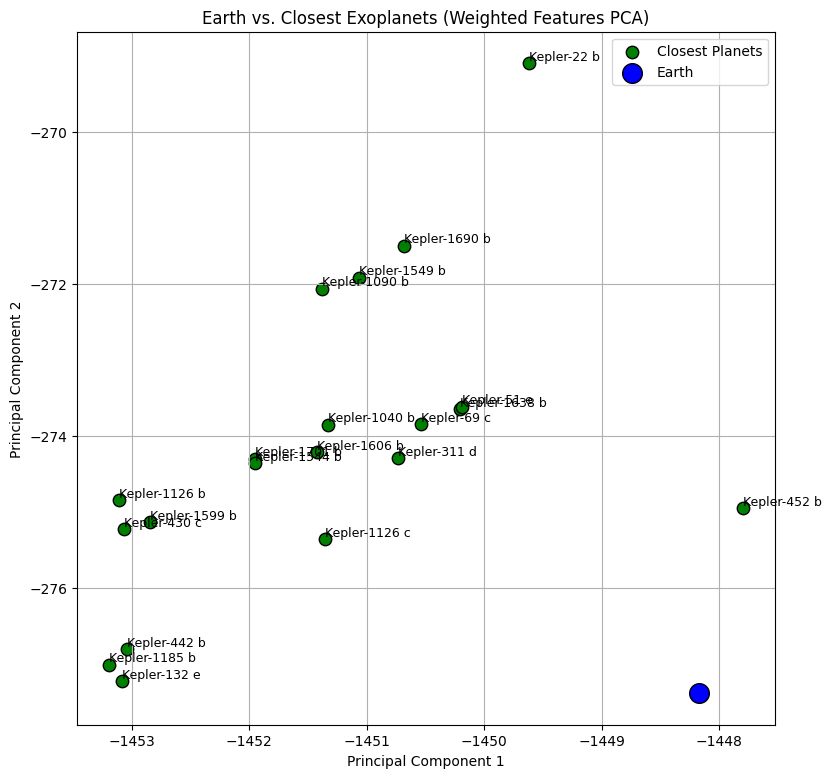

In [148]:
# Combine Earth as an additional row onto the weighted dataset
all_data = np.vstack([new_exoplanets_filtered_KNN_weighted, earth_weighted])

# Perform PCA directly on the weighted data (no scaling)
pca = PCA(n_components=2)
data_pca = pca.fit_transform(all_data)

# Convert PCA output to DataFrame
df_pca = pd.DataFrame(data_pca[:-1], index=new_exoplanets_filtered_KNN_weighted.index, columns=['PC1', 'PC2'])  # Exoplanets PCA coordinates
earth_pca = data_pca[-1]  # Earth's PCA coordinates

# Filter to only include Earth and the 10 closest planets
df_pca_closest = df_pca.loc[closest_planets_euc]

# Create the scatter plot
plt.figure(figsize=(9, 9))

# Plot only the closest planets
plt.scatter(df_pca_closest['PC1'], df_pca_closest['PC2'], c='green', label='Closest Planets', s=80, edgecolors='black')

# Highlight Earth
plt.scatter(earth_pca[0], earth_pca[1], c='blue', label='Earth', s=200, edgecolors='black')

# Annotate planet names
for planet, (x, y) in df_pca_closest.iterrows():
    plt.text(x, y, planet, fontsize=9, verticalalignment='bottom', horizontalalignment='left')

# Set labels and title
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Earth vs. Closest Exoplanets (Weighted Features PCA)')
plt.legend()
plt.grid()
plt.show()

In [149]:
!pip install adjustText

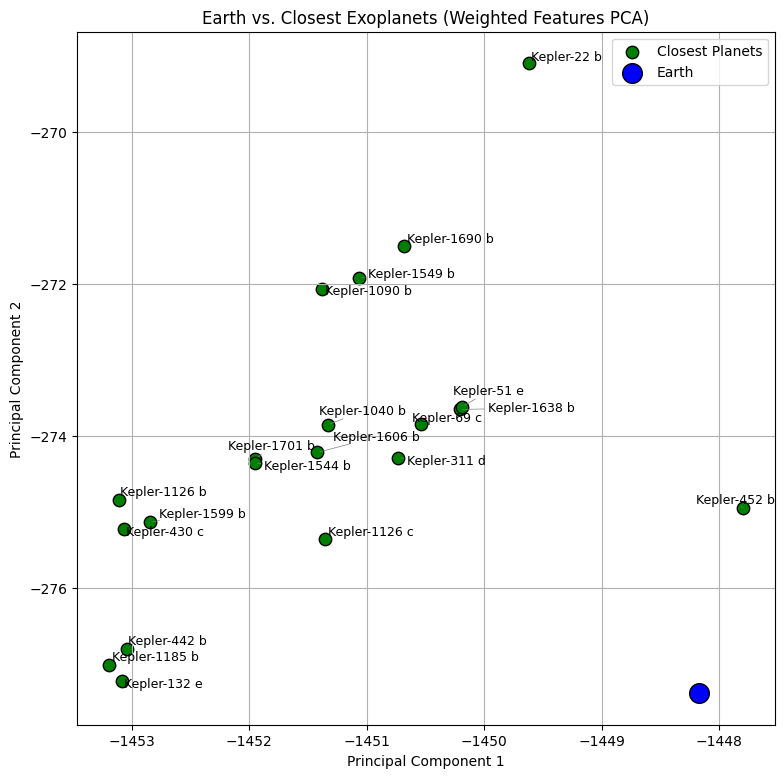

In [150]:
from adjustText import adjust_text

# Combine Earth as an additional row onto the weighted dataset
all_data = np.vstack([new_exoplanets_filtered_KNN_weighted, earth_weighted])

# Perform PCA directly on the weighted data (no scaling)
pca = PCA(n_components=2)
data_pca = pca.fit_transform(all_data)

# Convert PCA output to DataFrame
df_pca = pd.DataFrame(data_pca[:-1], index=new_exoplanets_filtered_KNN_weighted.index, columns=['PC1', 'PC2'])
earth_pca = data_pca[-1]  # Earth's PCA coordinates

# Filter to only include Earth and the 10 closest planets
df_pca_closest = df_pca.loc[closest_planets_euc]

# Create the scatter plot
plt.figure(figsize=(9, 9))

# Plot closest planets
plt.scatter(df_pca_closest['PC1'],
            df_pca_closest['PC2'],
            c='green',
            label='Closest Planets',
            s=80,
            edgecolors='black')

# Plot Earth
plt.scatter(earth_pca[0],
            earth_pca[1],
            c='blue',
            label='Earth',
            s=200,
            edgecolors='black')

# Store text objects for adjustment
texts = []
for planet, (x, y) in df_pca_closest.iterrows():
    texts.append(plt.text(x, y, planet, fontsize=9))

# Automatically adjust text positions to avoid overlap
adjust_text(
    texts,
    only_move={'points':'y', 'texts':'xy'},  # restrict movement for clarity
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5)
)

# Labels, title, legend, grid
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Earth vs. Closest Exoplanets (Weighted Features PCA)')
plt.legend()
plt.grid(True)
plt.show()

#### **Interpreting Reuslts of PCA Visualization Graph:**
Principal Component Analysis (PCA) of the weighted feature space reveals that Earth lies within a compact neighborhood of top-ranked exoplanet candidates identified via weighted Euclidean KNN. The closest 5 planets cluster tightly near Earth in the reduced two-dimensional projection, indicating stable similarity relationships in high-dimensional space.

Some dispersion among lower-ranked candidates is observed, consistent with increased metric sensitivity beyond the strongest analogs. Overall, the PCA visualization supports the robustness of the highest-ranked Earth analogs.

Earth appears to be on the outer edge of the similarity cluster of the top 5 Earth-Like exoplanets which indicates the unqiue compostion of Earth comapred to all astrophysical populations. Kepler-452 b which is the most Earth-Like planet appears to be within the clostest distance ot Earth as expected but it is also present withint he outer edge. This indicates that Kepler-452 b has a unqiue composition as well. Interestingly, Kepler-22 b appears to be seperated from all other clusters of planets. This is supported by the fact that all its features displayed strong similarity to Earth with the exception of its mass which is larger by 9.1 times.

---
Note:
* PCA uses Euclidean distance rather than Manhattan Distance (metric='minkowski', p=1) which is used in the KNN model #1
* Because PCA maximizes variance rather than preserving pairwise distances, spatial proximity in the projection is an approximation of true Euclidean similarity.

This means:
* PCA preserves variance under Euclidean assumptions.
* KNN neighbor selection used L1 distance.
* The 2D PCA projection may distort L1 neighborhood relationships.

What the Graph Ultimately Shows:
* The weighting used created a meaningful similarity neighborhood.
* The top candidates are not randomly selected.
* The Euclidean metric is producing coherent structure.
* The model is not behaving chaotically.

---
## **Unsupervised Learning - K Means Clustering Model**

Clustering is an unsupervised learning technique used to group data points into clusters based on their similarity. Unlike classification, clustering doesn’t require labeled data; it automatically identifies patterns or structures within the dataset by grouping similar data points.

K Means Clustering will be used to identify the natural groupings of all exoplanets. Then, the K Means Clustering model will be applied to the top 20 most Earth-Like exoplanets from the KNN Model #1 and KNN Model #2 to predict the cluster/group which they most liekly belong to.

The K Means cluster will be partitioned into k number of clusters. Partitions the data into a predefined number of clusters (k) by minimizing the variance within clusters. For the K Means Cluster Model #1, the data will be encoded using OneHotEncoder for categorical features then all features will be scaled. Outliers (exoplanets which exhibit large and/or anomolous values) will be kept. This will have 6 clusters (k=6). For the K Means Cluster Model #2, the data will be encoded using OneHotEncoder for categorical features then all features will be scaled. Outliers (exoplanets which exhibit large and/or anomolous values) will be removed. This will have 4 clusters (k=4).

Assumptions of K Means Clustering:
* K Means clustering assumes the spherical clusters. However most astrphysical data often contain outliers which can skew and distort centroids. Therefore, two K Means clustering models will be used and compared one one contains outleirs and the other removes outleirs.
* K Means clustering assumes clusters have a similar number of data points and roughly equal density, often failing when one cluster is significantly larger or denser than another.
* K Means clustering assumes data is assumed to have a consistent level of variance across all groups.
* K Means clustering assumes continuous numerical data and uses Euclidean distance to compute distances between points and centroids.
* Features with larger ranges can dominate the model, so it is assumed that features are standardized/normalized before clustering

#### **Preparing Dataset for Unsupervised Learning using K Means Clustering Model and Unsupervised Learning using PCA Visualization**

In [151]:
# general importing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# K Means Clustering importing
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# regex importing for pattern recognition
import re

In [152]:
# creating a copy of the dataset to use for K Means Clustering
new_exoplanets_filtered_KMeans = new_exoplanets_filtered4.copy()

#### Normalizing all features which were not previously normalized in terms of earth

In [153]:
# Normalize the orbital period column
new_exoplanets_filtered_KMeans['orbital_period_day'] = new_exoplanets_filtered_KMeans['orbital_period_day'] / 365.26

# Normalize the planet equilibrium temperature
new_exoplanets_filtered_KMeans['planet_equil_temp_k'] = new_exoplanets_filtered_KMeans['planet_equil_temp_k'] / 255.0

# Normalize the stellar effective temperature
new_exoplanets_filtered_KMeans['stellar_effective_temp_k'] = new_exoplanets_filtered_KMeans['stellar_effective_temp_k'] / 5772.0

In [154]:
# setting the planet_name as the index
new_exoplanets_filtered_KMeans.set_index('planet_name', inplace=True)

In [155]:
new_exoplanets_filtered_KMeans

,star_number_per_system,spectral_type,orbital_period_day,orbit_semi_major_axis_au,planet_rad_earth_rad,planet_mass_earth_mass,planet_equil_temp_k,stellar_effective_temp_k,stellar_rad_solar_rad,stellar_mass_solar_mass,stellar_surf_grav,stellar_luminosity_solar_lum,planet_orbital_velocity,habitable_zone_main_seq
planet_name,,,,,,,,,,,,,,
11 Com b,2.0,GIII,0.888737,1.226000,61.636581,5505.066162,2.561322,0.832987,13.760000,2.090000,2.380000,90.778824,1.305879,0
11 UMi b,1.0,KIII,1.413295,1.526667,57.057421,4684.814200,2.856345,0.740904,26.935000,2.780000,1.765000,217.709668,1.349663,0
14 And b,1.0,KIII,0.510048,0.761667,30.026230,1224.550434,2.967550,0.840350,11.275000,1.780000,2.590000,63.134826,1.528982,0
14 Her b,1.0,KV,4.835948,2.814750,42.726171,2559.472162,0.501817,0.917704,0.999085,0.904000,4.418006,0.705033,0.566812,0
16 Cyg B b,3.0,GV,2.188510,1.662833,20.176910,533.514528,0.750641,0.992480,1.129135,1.016599,4.342293,1.231895,0.782034,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ups And b,2.0,FV,0.012638,0.058895,13.205018,219.960419,5.110508,1.063378,1.614742,1.276049,4.161529,3.320113,4.655553,0
ups And c,2.0,FV,0.659061,0.827712,21.840560,629.595000,1.358604,1.059787,1.614742,1.301399,4.148705,3.275493,1.254124,0
ups And d,2.0,FV,3.518990,2.528382,31.047562,1313.220000,0.777340,1.059787,1.614742,1.301399,4.148705,3.275493,0.717561,0


In [156]:
new_exoplanets_filtered_KMeans.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5419 entries, 11 Com b to xi Aql b
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   star_number_per_system        5419 non-null   float64
 1   spectral_type                 5419 non-null   object 
 2   orbital_period_day            5419 non-null   float64
 3   orbit_semi_major_axis_au      5419 non-null   float64
 4   planet_rad_earth_rad          5419 non-null   float64
 5   planet_mass_earth_mass        5419 non-null   float64
 6   planet_equil_temp_k           5419 non-null   float64
 7   stellar_effective_temp_k      5419 non-null   float64
 8   stellar_rad_solar_rad         5419 non-null   float64
 9   stellar_mass_solar_mass       5419 non-null   float64
 10  stellar_surf_grav             5419 non-null   float64
 11  stellar_luminosity_solar_lum  5419 non-null   float64
 12  planet_orbital_velocity       5419 non-null   float64
 1

#### Using OneHotEncoder to encode spectral type column

In [157]:
# using OneHotEncoder to encode spectral_type column (categorical column)
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_array = encoder.fit_transform(new_exoplanets_filtered_KMeans[['spectral_type']])

# Convert to DataFrame
new_exoplanets_filtered_KMeans_encoded = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out(['spectral_type']),
    index=new_exoplanets_filtered_KMeans.index
)

# dropping original spectral_type column from dataset
new_exoplanets_filtered_KMeans = new_exoplanets_filtered_KMeans.drop(columns=['spectral_type'])

# Add encoded columns
new_exoplanets_filtered_KMeans = pd.concat([new_exoplanets_filtered_KMeans, new_exoplanets_filtered_KMeans_encoded], axis=1)

In [158]:
new_exoplanets_filtered_KMeans_encoded

,spectral_type_AIII,spectral_type_AIV,spectral_type_AV,spectral_type_BIV,spectral_type_BV,spectral_type_FIV,spectral_type_FV,spectral_type_GII,spectral_type_GIII,spectral_type_GIV,...,spectral_type_KII,spectral_type_KIII,spectral_type_KIV,spectral_type_KV,spectral_type_MIII,spectral_type_MV,spectral_type_SD,spectral_type_T,spectral_type_WD,spectral_type_sdB
planet_name,,,,,,,,,,,,,,,,,,,,,
11 Com b,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11 UMi b,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14 And b,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14 Her b,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
16 Cyg B b,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ups And b,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ups And c,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ups And d,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [159]:
new_exoplanets_filtered_KMeans

,star_number_per_system,orbital_period_day,orbit_semi_major_axis_au,planet_rad_earth_rad,planet_mass_earth_mass,planet_equil_temp_k,stellar_effective_temp_k,stellar_rad_solar_rad,stellar_mass_solar_mass,stellar_surf_grav,...,spectral_type_KII,spectral_type_KIII,spectral_type_KIV,spectral_type_KV,spectral_type_MIII,spectral_type_MV,spectral_type_SD,spectral_type_T,spectral_type_WD,spectral_type_sdB
planet_name,,,,,,,,,,,,,,,,,,,,,
11 Com b,2.0,0.888737,1.226000,61.636581,5505.066162,2.561322,0.832987,13.760000,2.090000,2.380000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11 UMi b,1.0,1.413295,1.526667,57.057421,4684.814200,2.856345,0.740904,26.935000,2.780000,1.765000,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14 And b,1.0,0.510048,0.761667,30.026230,1224.550434,2.967550,0.840350,11.275000,1.780000,2.590000,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14 Her b,1.0,4.835948,2.814750,42.726171,2559.472162,0.501817,0.917704,0.999085,0.904000,4.418006,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
16 Cyg B b,3.0,2.188510,1.662833,20.176910,533.514528,0.750641,0.992480,1.129135,1.016599,4.342293,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ups And b,2.0,0.012638,0.058895,13.205018,219.960419,5.110508,1.063378,1.614742,1.276049,4.161529,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ups And c,2.0,0.659061,0.827712,21.840560,629.595000,1.358604,1.059787,1.614742,1.301399,4.148705,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ups And d,2.0,3.518990,2.528382,31.047562,1313.220000,0.777340,1.059787,1.614742,1.301399,4.148705,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Scaling all features

In [160]:
# scaling all features of the dataset using StandardScaler
scaler = StandardScaler()
new_exoplanets_filtered_KMeans_scaled = scaler.fit_transform(new_exoplanets_filtered_KMeans)

# Convert to DataFrame
new_exoplanets_filtered_KMeans_scaled = pd.DataFrame(
    new_exoplanets_filtered_KMeans_scaled,
    columns=new_exoplanets_filtered_KMeans.columns,
    index=new_exoplanets_filtered_KMeans.index
)

### **K Means Clustering Model #1 (With One Hot Encoding on Categorical Features + Standard Scaling on all Features + Outliers Not Removed)**

In [161]:
# creating a K Means pipeline with 6 clusters
kmeans_pipeline = Pipeline([
    ('kmeans', KMeans(n_clusters=6, random_state=42))
])

# fit and predict our clusters
kmeans_labels = kmeans_pipeline.fit_predict(new_exoplanets_filtered_KMeans_scaled)

print(kmeans_labels)

[4 4 4 ... 3 4 4]


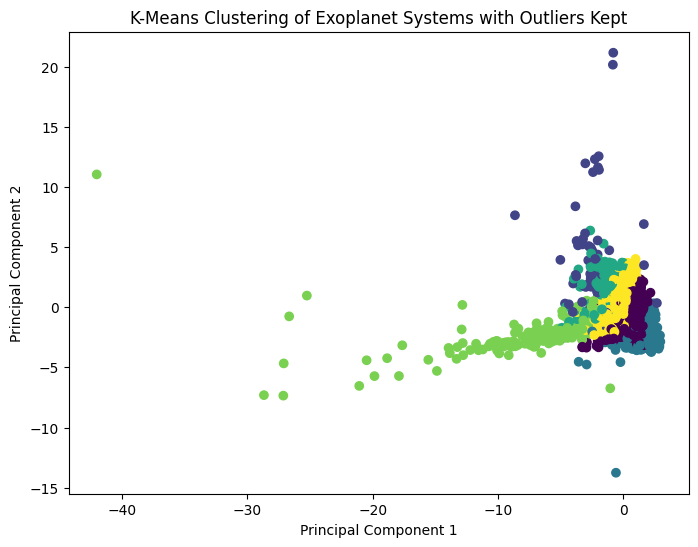

In [162]:
#visual using PCA
pca = PCA(n_components=6)
data_pca = pca.fit_transform(new_exoplanets_filtered_KMeans_scaled)

# Now use kmeans_labels (which holds the cluster assignments) for coloring the scatter plot
plt.figure(figsize=(8,6))
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=kmeans_labels)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clustering of Exoplanet Systems with Outliers Kept')
plt.show()

The PCA graph shows mild seperation along the PC1 direction. Given the large number of dimensions (34) which are compressed into 2D, we expect imerfect seperation. Majority of the clusters overlap tightly with the exception of the light green green which stretches leftward. Thi indicates that there may be outliers present (anomolous exoplanets which exhibit extreme properties). So, a second K Means clustering model will be created where outliers are removed.

In [163]:
# seeing how accurate our model was at clustering
kmeans_score = silhouette_score(new_exoplanets_filtered_KMeans_scaled, kmeans_labels)
print("Silhouette Score for K-Means Clustering: ", kmeans_score)

Silhouette Score for K-Means Clustering:  0.40149036542370325


The Silhouette Score is a metric used to evaluate the quality of clusters in clustering analysis. It provides a measure of how similar each point is to its own cluster compared to other clusters. It ranges from -1 to 1, where:

* 1: Indicates that points are well matched to their own cluster and distinct from other clusters (ideal clustering).
* 0: Indicates overlapping clusters, meaning the boundary between clusters is unclear.
* -1: Indicates that points are likely assigned to the wrong cluster, meaning they’re closer to points in a different cluster.

The silhouette score is especially useful when the true labels are not available, as it allows us to assess clustering quality without supervision.

A silhoutee score of 0.402 implies moderate structure which implies the clusters are reasonably seperated though there will be overlap present. There is real structure though these structures do not present extreme distinction (ideal case would prefer extreme distinction). Given that astrophysical data is continuous and that K Means clustering assumes spherical clusters in feature space, a silhoutte score of 0.402 is very reasonable since astrophysical data would typically form elliptical clusters due to elongated distrubtions caused by the presense of outliers (for ex. extreme long-period planets) which distort centroids.

In [164]:
# interpreting centroid cluster values to interpret planetary system
kmeans = KMeans(n_clusters=6, random_state=42)
kmeans.fit(new_exoplanets_filtered_KMeans_scaled)

# Get column names BEFORE scaling
feature_columns = new_exoplanets_filtered_KMeans.columns

# Inverse transform cluster centers back to original scale
cluster_centers_original = scaler.inverse_transform(kmeans.cluster_centers_)

# Convert to DataFrame
cluster_centers_df = pd.DataFrame(
    cluster_centers_original,
    columns=feature_columns
)

cluster_centers_transposed = cluster_centers_df.T
cluster_centers_transposed

,0,1,2,3,4,5
star_number_per_system,1.094814e+00,1.239766e+00,1.119658e+00,1.112849e+00,1.131222e+00,1.072016e+00
orbital_period_day,4.742352e-01,6.201422e+00,2.399063e+03,3.246319e-01,3.091520e+00,5.144647e-01
orbit_semi_major_axis_au,2.265085e+00,7.282362e+00,1.891750e+01,1.033439e+00,3.360219e+00,3.464689e-01
planet_rad_earth_rad,4.498484e+00,1.592749e+01,3.783631e+00,7.474944e+00,3.091414e+01,5.898266e+00
planet_mass_earth_mass,1.382885e+02,1.028911e+03,1.538175e+02,2.986042e+02,1.838788e+03,1.701045e+02
planet_equil_temp_k,2.789767e+00,4.951828e+00,1.906494e+00,4.208276e+00,2.203881e+00,3.378490e+00
stellar_effective_temp_k,8.165520e-01,1.316310e+00,6.120199e-01,1.077357e+00,8.384160e-01,9.799559e-01
stellar_rad_solar_rad,7.649616e-01,1.870064e+00,4.079853e-01,1.353599e+00,1.297317e+01,1.066114e+00
stellar_mass_solar_mass,7.494505e-01,1.365508e+00,4.024159e-01,1.194352e+00,1.735434e+00,9.843920e-01
stellar_surf_grav,4.571523e+00,4.183794e+00,4.839084e+00,4.265783e+00,2.782966e+00,4.389964e+00


**Interpretation of Cluster 0: Warm gaseous subgiants orbiting cool Type K main sequence stars**
* The dominant spectral type are main sequence Type K stars (spectral_type_KV = 1.000)
* Orbital period: 0.47 years (~170 days)
* Semi-major axis: 2.27 AU
* Planet mass: 138 Earth masses (Mp,☉) (~Saturn-Like)
* Planet radius: 4.5 Earth radii (Rp,☉) (~Super-Neptune-Like)
* Planet Equilibrium Temperature: 2.79 Earth Equilibrium temp (Teq,☉)
* Stellar Luminosity: 0.46 Sun Luminosity (L☉)
* Stellar Effective Temperature: 0.82 Sun Effective Temp (Teff,☉)
* Stellar mass: 0.75 Sun mass (Ms,☉)
* Stellar radius: 0.77 Sun radii (Rs,☉)

**These exoplanets are likely warm Super-Neptune-like orbiting cool K Main Sequence stars in relatively compact systems hosting moderate-mass planets at moderate distances.**

---
**Interpretation of Cluster 1: hot massive gaseous giants orbiting hot evolved subgiant stars**
* Mix of FIV, GIV, some A-types dominate (hotter subgiants and hotter massive main sequence stars)
* Orbital period: 6.2 years (~2,264 days)
* Semi-major axis: 7.3 AU
* Planet mass: 1028 Earth masses (Mp,☉) (~Jupiter-Like)
* Planet radius: 15.9 Earth radii (Rp,☉) (~Super-Jupiter-Like)
* Planet Equilibrium Temperature: 4.95 Earth Equilibrium temp (Teq,☉)
* Stellar Luminosity: 8 Sun Luminosity (L☉)
* Stellar Effective Temperature: 1.32 Sun Effective Temp (Teff,☉)
* Stellar mass: 1.36 Sun mass (Ms,☉)
* Stellar radius: 1.87 Sun radii (Rs,☉)

**These exoplanets are likely hot massive Jupiter-Like orbiting hot luminous evolved subgiants in relatively wide systems hosting highly massive planets at relatively wide distances.**

---
**Interpretation of Cluster 2: long period massive dense rocky planets (super-earth-like) orbiting cool Type M red dwarfs in wide system**
* The dominant spectral type are main sequence Type M stars (spectral_type_MV = 1.000)
* Orbital period: 2399 years (~875,635 days)
* Semi-major axis: 19 AU
* Planet mass: 154 Earth masses (Mp,☉) (~Super-Saturn-Like)
* Planet radius: 3.78 Earth radii (Rp,☉) (~Super-Earth-Like)
* Planet Equilibrium Temperature: 1.91 Earth Equilibrium temp (Teq,☉)
* Stellar Luminosity: 0.03 Sun Luminosity (L☉)
* Stellar Effective Temperature: 0.6 Sun Effective Temp (Teff,☉)
* Stellar mass: 0.4 Sun mass (Ms,☉)
* Stellar radius: 0.4 Sun radii (Rs,☉)

**These exoplanets are likely massive dense Super-Earth like orbiting cool Type M main sequence (red dwarfs) in wide systems hosting planets at extremely wide distances with long periods. There are likely major outliers which dominate this cluster.**

---
**Interpretation of Cluster 3: hot gaseous subgiants orbiting hot Type F main sequence stars in compact system**
* The dominant spectral type are main sequence Type F stars (spectral_type_FV = 0.999)
* Orbital period: 0.32 years (~120 days)
* Semi-major axis: 1.03 AU
* Planet mass: 298 Earth masses (Mp,☉) (~Super-Saturn-Like)
* Planet radius: 7.48 Earth radii (Rp,☉) (~Saturn-Like)
* Planet Equilibrium Temperature: 4.21 Earth Equilibrium temp (Teq,☉)
* Stellar Luminosity: 2.62 Sun Luminosity (L☉)
* Stellar Effective Temperature: 1.07 Sun Effective Temp (Teff,☉)
* Stellar mass: 1.19 Sun mass (Ms,☉)
* Stellar radius: 1.35 Sun radii (Rs,☉)

**These exoplanets are likely hot saturns orbiting around Type F main sequence stars at short distances.**

---
**Interpretation of Cluster 4: Warm massive dense gaseous giants orbiting hot giant stars in relatively wide systems**
* Large mix of KIII, KIV, GIII dominate (giant stars)
* Orbital period: 3.09 years (~1,128 days)
* Semi-major axis: 3.36 AU
* Planet mass: 1838 Earth masses (Mp,☉) (~Jupiter-Like)
* Planet radius: 30.9 Earth radii (Rp,☉) (~Neptune-Like)
* Planet Equilibrium Temperature: 2.2 Earth Equilibrium temp (Teq,☉)
* Stellar Luminosity: 138 Sun Luminosity (L☉)
* Stellar Effective Temperature: 1.07 Sun Effective Temp (Teff,☉)
* Stellar mass: 1.74 Sun mass (Ms,☉)
* Stellar radius: 12.97 Sun radii (Rs,☉)
* **These exoplanets are likely warm massive dense Neptune-like orbiting evolved subgiant stars orbitting hot giant stars in relatively wide systems hosting planets at moderate distances.**

---
**Interpretation of Cluster 5: Warm gaseous subgiants orbitting Sun-Like stars in compact systems**
* The dominant spectral type are main sequence Type G stars (spectral_type_GV = 0.991)
* Orbital period: 0.51 years (~186 days)
* Semi-major axis: 0.52 AU
* Planet mass: 170 Earth masses (Mp,☉) (~Super-Saturn-Like)
* Planet radius: 5.9 Earth radii (Rp,☉) (~Super-Neptune-Like)
* Planet Equilibrium Temperature: 3.39 Earth Equilibrium temp (Teq,☉)
* Stellar Luminosity: 1.16 Sun Luminosity (L☉)
* Stellar Effective Temperature: 0.97 Sun Effective Temp (Teff,☉)
* Stellar mass: 0.98 Sun mass (Ms,☉)
* Stellar radius: 1.07 Sun radii (Rs,☉)
* **These exoplanets are likely warm Super-Neptune-like orbiting Type G (Sun-Like) Main Sequence stars in compact systems hosting stars at short distances.**

---

The results revealed six astrophysically distinct planetary system classes primarily differentiated by spectral type based on star type and the star evolutionary stage, orbital period, orbital semi major axis, planet equilibrium temperature, and all other stellar parameters. All other planetary features were not able to accurately seperate clusters due to the high variability within planetary features, particularly within the planet mass and radius. The K Means clustering model independently grouped clusters where:
* Cluster 0: Type K Main Sequence Star Planetary system
* Cluster 1: Hot Evolved Subgiant Star planetary system
* Cluster 2: Red Dwarf Wide Orbit Planetary System
* Cluster 3: Type F Main Sequence Star Planetary system
* Cluster 4: Hot Giant Star planetary system
* Cluster 5: Sun-Like Planetary System

In [165]:
# renaming the clusters based on the interpretation
cluster_centers_transposed.columns = [
    "Type K Main Sequence Star Planetary system",
    "Hot Evolved Subgiant Star planetary system",
    "Red Dwarf Wide Orbit Planetary System",
    "Type F Main Sequence Star Planetary system",
    "Hot Giant Star planetary system",
    "Sun-Like Planetary System"
]

cluster_centers_transposed

,Type K Main Sequence Star Planetary system,Hot Evolved Subgiant Star planetary system,Red Dwarf Wide Orbit Planetary System,Type F Main Sequence Star Planetary system,Hot Giant Star planetary system,Sun-Like Planetary System
star_number_per_system,1.094814e+00,1.239766e+00,1.119658e+00,1.112849e+00,1.131222e+00,1.072016e+00
orbital_period_day,4.742352e-01,6.201422e+00,2.399063e+03,3.246319e-01,3.091520e+00,5.144647e-01
orbit_semi_major_axis_au,2.265085e+00,7.282362e+00,1.891750e+01,1.033439e+00,3.360219e+00,3.464689e-01
planet_rad_earth_rad,4.498484e+00,1.592749e+01,3.783631e+00,7.474944e+00,3.091414e+01,5.898266e+00
planet_mass_earth_mass,1.382885e+02,1.028911e+03,1.538175e+02,2.986042e+02,1.838788e+03,1.701045e+02
planet_equil_temp_k,2.789767e+00,4.951828e+00,1.906494e+00,4.208276e+00,2.203881e+00,3.378490e+00
stellar_effective_temp_k,8.165520e-01,1.316310e+00,6.120199e-01,1.077357e+00,8.384160e-01,9.799559e-01
stellar_rad_solar_rad,7.649616e-01,1.870064e+00,4.079853e-01,1.353599e+00,1.297317e+01,1.066114e+00
stellar_mass_solar_mass,7.494505e-01,1.365508e+00,4.024159e-01,1.194352e+00,1.735434e+00,9.843920e-01
stellar_surf_grav,4.571523e+00,4.183794e+00,4.839084e+00,4.265783e+00,2.782966e+00,4.389964e+00


In [166]:
cluster_names = {
    0: "K-Type Main Sequence Planetary System",
    1: "Hot Subgiant Star Planetary System",
    2: "Red Dwarf Wide-Orbit Planetary System",
    3: "F-Type Main Sequence Planetary System",
    4: "Hot Giant Star Planetary System",
    5: "Sun-Like Planetary System"
}

# predicting which clusters the top 20 Earth Like exoplanets belong to

# standardizing top 20 Earth-Like plansts list from the manhattan distance KNN model
closest_planets_man_list_scaled = scaler.transform(closest_planets_man_list)
# standardizing top 20 Earth-Like plansts list from the euclidean distance KNN model
closest_planets_euc_list_scaled = scaler.transform(closest_planets_euc_list)

# Predict the cluster for the top 20 Earth Like exoplanets using K-Means
predict_cluster_man = kmeans_pipeline.predict(closest_planets_man_list_scaled)
predict_cluster_euc = kmeans_pipeline.predict(closest_planets_euc_list_scaled)

# Print results
print("Top 20 Earth-Like Exoplanets using Manhattan Distance (KNN Model #1 Results):")
for i in range(20):
    cluster_id = predict_cluster_man[i]
    print(f"{i+1}. {closest_planets_man[i]} (Cluster: {cluster_names[cluster_id]})")


print("\nTop 20 Earth-Like Exoplanets using Euclidean Distance (KNN Model #2 Results):")
for i in range(20):
    cluster_id = predict_cluster_euc[i]
    print(f"{i+1}. {closest_planets_euc[i]} (Cluster: {cluster_names[cluster_id]})")

Top 20 Earth-Like Exoplanets using Manhattan Distance (KNN Model #1 Results):
1. Kepler-452 b (Cluster: Sun-Like Planetary System)
2. Kepler-1638 b (Cluster: Sun-Like Planetary System)
3. Kepler-51 e (Cluster: Sun-Like Planetary System)
4. Kepler-1606 b (Cluster: Sun-Like Planetary System)
5. Kepler-1701 b (Cluster: Sun-Like Planetary System)
6. Kepler-22 b (Cluster: Sun-Like Planetary System)
7. Kepler-1126 c (Cluster: Sun-Like Planetary System)
8. Kepler-1549 b (Cluster: Sun-Like Planetary System)
9. Kepler-1690 b (Cluster: Sun-Like Planetary System)
10. Kepler-69 c (Cluster: Sun-Like Planetary System)
11. Kepler-1090 b (Cluster: Sun-Like Planetary System)
12. Kepler-1634 b (Cluster: Sun-Like Planetary System)
13. Kepler-1185 b (Cluster: Sun-Like Planetary System)
14. Kepler-311 d (Cluster: Sun-Like Planetary System)
15. Kepler-132 e (Cluster: Sun-Like Planetary System)
16. Kepler-442 b (Cluster: K-Type Main Sequence Planetary System)
17. Kepler-1554 b (Cluster: Sun-Like Planetary Sy

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [167]:
# viewing row for kepler-442 b
new_exoplanets_filtered4[new_exoplanets_filtered4['planet_name'] == 'Kepler-442 b']

,planet_name,star_number_per_system,spectral_type,orbital_period_day,orbit_semi_major_axis_au,planet_rad_earth_rad,planet_mass_earth_mass,planet_equil_temp_k,stellar_effective_temp_k,stellar_rad_solar_rad,stellar_mass_solar_mass,stellar_surf_grav,stellar_luminosity_solar_lum,planet_orbital_velocity,habitable_zone_main_seq
3652,Kepler-442 b,1.0,KV,112.30459,0.39508,1.472143,1.653236,255.25,4510.2,0.631196,0.6464,4.663674,0.147911,1.279332,1


In [168]:
# viewing row for kepler-1544 b
new_exoplanets_filtered4[new_exoplanets_filtered4['planet_name'] == 'Kepler-442 b']

,planet_name,star_number_per_system,spectral_type,orbital_period_day,orbit_semi_major_axis_au,planet_rad_earth_rad,planet_mass_earth_mass,planet_equil_temp_k,stellar_effective_temp_k,stellar_rad_solar_rad,stellar_mass_solar_mass,stellar_surf_grav,stellar_luminosity_solar_lum,planet_orbital_velocity,habitable_zone_main_seq
3652,Kepler-442 b,1.0,KV,112.30459,0.39508,1.472143,1.653236,255.25,4510.2,0.631196,0.6464,4.663674,0.147911,1.279332,1


In [169]:
# viewing row for kepler-438 b
new_exoplanets_filtered4[new_exoplanets_filtered4['planet_name'] == 'Kepler-438 b']

,planet_name,star_number_per_system,spectral_type,orbital_period_day,orbit_semi_major_axis_au,planet_rad_earth_rad,planet_mass_earth_mass,planet_equil_temp_k,stellar_effective_temp_k,stellar_rad_solar_rad,stellar_mass_solar_mass,stellar_surf_grav,stellar_luminosity_solar_lum,planet_orbital_velocity,habitable_zone_main_seq
3647,Kepler-438 b,1.0,KV,35.233096,0.16666,1.024286,1.031686,276.75,3738.6,0.528,0.556,4.697656,0.048865,1.826824,1


In [170]:
# viewing in table form
results_man = pd.DataFrame({
    "Planet": closest_planets_man,
    "Cluster_ID": predict_cluster_man
})
results_euc = pd.DataFrame({
    "Planet": closest_planets_euc,
    "Cluster_ID": predict_cluster_euc
})

results_man["Cluster_Type"] = results_man["Cluster_ID"].map(cluster_names)
results_euc["Cluster_Type"] = results_euc["Cluster_ID"].map(cluster_names)

print("Top 20 Earth-Like Exoplanets using Manhattan Distance (KNN Model #1 Results):\n")
print(results_man)
print("\nTop 20 Earth-Like Exoplanets using Euclidean Distance (KNN Model #2 Results):\n")
print(results_euc)

Top 20 Earth-Like Exoplanets using Manhattan Distance (KNN Model #1 Results):

           Planet  Cluster_ID                           Cluster_Type
0    Kepler-452 b           5              Sun-Like Planetary System
1   Kepler-1638 b           5              Sun-Like Planetary System
2     Kepler-51 e           5              Sun-Like Planetary System
3   Kepler-1606 b           5              Sun-Like Planetary System
4   Kepler-1701 b           5              Sun-Like Planetary System
5     Kepler-22 b           5              Sun-Like Planetary System
6   Kepler-1126 c           5              Sun-Like Planetary System
7   Kepler-1549 b           5              Sun-Like Planetary System
8   Kepler-1690 b           5              Sun-Like Planetary System
9     Kepler-69 c           5              Sun-Like Planetary System
10  Kepler-1090 b           5              Sun-Like Planetary System
11  Kepler-1634 b           5              Sun-Like Planetary System
12  Kepler-1185 b       

We would expect that for the most Earth-Like exoplanets, they are likely to orbit a Type GV (Sun-Like) star. The model was able to correctly predict the planetary system the top 20 Earth-analogus exoplanets identified by both KNN models based on the spectral type of their hsot stars. Overall, the model was accurate in predicting that a majority of the top-20 most Earth Like exoplanets from both KNN models correctly belong to a Sun-Like planetary system. Thus, ensuring model robustness.

Based on the limitations of the model to differentiate clusters based on all planetary features due the feature variabiltiy, the K Means cluster model is unable to idenfity the natural grouping of exoplanets based on what type of planet the exoplanets are. However, the model is able to correctly group exoplanets into planetary systems based on the type of host star they orbit. Therefore, exoplanets can be naturlly grouped based on their host star.


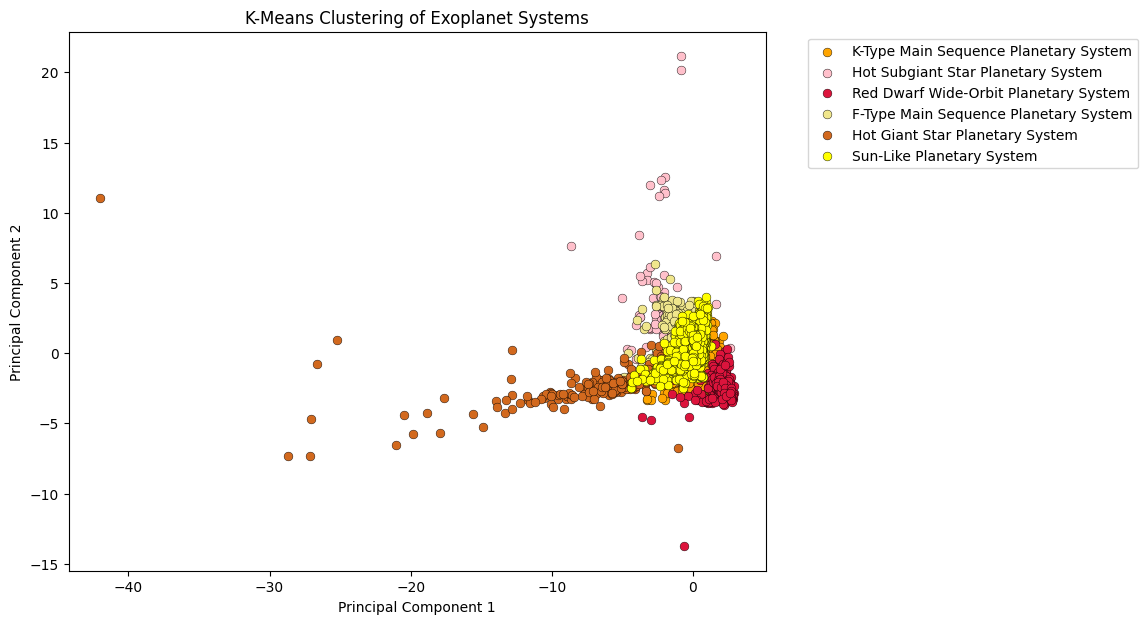

In [171]:
# rerunning PCA visualization with clusters labeled

# define cluster colors
cluster_colors = {
    0: "orange",
    1: "pink",
    2: "crimson",
    3: "khaki",
    4: "chocolate",
    5: "yellow"
}

# visualize using PCA
pca = PCA(n_components=6)
data_pca = pca.fit_transform(new_exoplanets_filtered_KMeans_scaled)

plt.figure(figsize=(9,7))

for cluster_id in range(6):

    # select points in this cluster
    cluster_points = data_pca[kmeans_labels == cluster_id]

    plt.scatter(
        cluster_points[:,0],
        cluster_points[:,1],
        color=cluster_colors[cluster_id],
        label=cluster_names[cluster_id],
        marker='o',
        s=40,
        edgecolors='black',
        linewidths=0.3,
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering of Exoplanet Systems")

plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()

### **K Means Clustering Model #2 (With One Hot Encoding on Categorical Features + Standard Scaling on all Features + Outliers Removed)**

In [172]:
# Set Z-score threshold
z_threshold = 6

# Compute absolute Z-scores (already standardized)
z_scores = np.abs(new_exoplanets_filtered_KMeans_scaled)

# Identify rows where all features are within threshold
non_outliers_mask = (z_scores < z_threshold).all(axis=1)

# Filter dataset
new_exoplanets_filtered_KMeans_cleaned = new_exoplanets_filtered_KMeans_scaled[non_outliers_mask]

print("Original dataset size:", new_exoplanets_filtered_KMeans_scaled.shape)
print("Dataset size after outlier removal:", new_exoplanets_filtered_KMeans_cleaned.shape)
print("Number of removed planets:",
      new_exoplanets_filtered_KMeans_scaled.shape[0] - new_exoplanets_filtered_KMeans_cleaned.shape[0])

Original dataset size: (5419, 34)
Dataset size after outlier removal: (4884, 34)
Number of removed planets: 535


In [173]:
new_exoplanets_filtered_KMeans_scaled

,star_number_per_system,orbital_period_day,orbit_semi_major_axis_au,planet_rad_earth_rad,planet_mass_earth_mass,planet_equil_temp_k,stellar_effective_temp_k,stellar_rad_solar_rad,stellar_mass_solar_mass,stellar_surf_grav,...,spectral_type_KII,spectral_type_KIII,spectral_type_KIV,spectral_type_KV,spectral_type_MIII,spectral_type_MV,spectral_type_SD,spectral_type_T,spectral_type_WD,spectral_type_sdB
planet_name,,,,,,,,,,,,,,,,,,,,,
11 Com b,2.751375,-0.013845,-0.015284,5.488809,6.200386,-0.372991,-0.440199,3.146686,2.942388,-4.554851,...,-0.019215,-0.145273,-0.124719,-0.545291,-0.033293,-0.307451,-0.013586,-0.013586,-0.023535,-0.033293
11 UMi b,-0.291421,-0.013810,-0.012441,5.028836,5.227429,-0.214607,-0.850007,6.527983,4.735835,-5.957191,...,-0.019215,6.883599,-0.124719,-0.545291,-0.033293,-0.307451,-0.013586,-0.013586,-0.023535,-0.033293
14 And b,-0.291421,-0.013870,-0.019675,2.313573,1.122972,-0.154905,-0.407430,2.508923,2.136636,-4.076003,...,-0.019215,6.883599,-0.124719,-0.545291,-0.033293,-0.307451,-0.013586,-0.013586,-0.023535,-0.033293
14 Her b,-0.291421,-0.013581,-0.000262,3.589272,2.706414,-1.478644,-0.063172,-0.128339,-0.140261,0.092265,...,-0.019215,-0.145273,-0.124719,1.833882,-0.033293,-0.307451,-0.013586,-0.013586,-0.023535,-0.033293
16 Cyg B b,5.794171,-0.013758,-0.011154,1.324216,0.303286,-1.345062,0.269615,-0.094962,0.152406,-0.080377,...,-0.019215,-0.145273,-0.124719,-0.545291,-0.033293,-0.307451,-0.013586,-0.013586,-0.023535,-0.033293
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ups And b,2.751375,-0.013904,-0.026320,0.623895,-0.068642,0.995550,0.585145,0.029667,0.826769,-0.492560,...,-0.019215,-0.145273,-0.124719,-0.545291,-0.033293,-0.307451,-0.013586,-0.013586,-0.023535,-0.033293
ups And c,2.751375,-0.013860,-0.019050,1.491328,0.417254,-1.018675,0.569164,0.029667,0.892658,-0.521801,...,-0.019215,-0.145273,-0.124719,-0.545291,-0.033293,-0.307451,-0.013586,-0.013586,-0.023535,-0.033293
ups And d,2.751375,-0.013669,-0.002970,2.416165,1.228149,-1.330728,0.569164,0.029667,0.892658,-0.521801,...,-0.019215,-0.145273,-0.124719,-0.545291,-0.033293,-0.307451,-0.013586,-0.013586,-0.023535,-0.033293


In [174]:
new_exoplanets_filtered_KMeans_cleaned

,star_number_per_system,orbital_period_day,orbit_semi_major_axis_au,planet_rad_earth_rad,planet_mass_earth_mass,planet_equil_temp_k,stellar_effective_temp_k,stellar_rad_solar_rad,stellar_mass_solar_mass,stellar_surf_grav,...,spectral_type_KII,spectral_type_KIII,spectral_type_KIV,spectral_type_KV,spectral_type_MIII,spectral_type_MV,spectral_type_SD,spectral_type_T,spectral_type_WD,spectral_type_sdB
planet_name,,,,,,,,,,,,,,,,,,,,,
14 Her b,-0.291421,-0.013581,-0.000262,3.589272,2.706414,-1.478644,-0.063172,-0.128339,-0.140261,0.092265,...,-0.019215,-0.145273,-0.124719,1.833882,-0.033293,-0.307451,-0.013586,-0.013586,-0.023535,-0.033293
16 Cyg B b,5.794171,-0.013758,-0.011154,1.324216,0.303286,-1.345062,0.269615,-0.094962,0.152406,-0.080377,...,-0.019215,-0.145273,-0.124719,-0.545291,-0.033293,-0.307451,-0.013586,-0.013586,-0.023535,-0.033293
1RXS J160929.1-210524 b,-0.291421,-0.013841,3.093417,1.170538,3.389977,1.936245,-1.029852,-0.042749,-0.280618,-0.870186,...,-0.019215,-0.145273,-0.124719,1.833882,-0.033293,-0.307451,-0.013586,-0.013586,-0.023535,-0.033293
2M0437 b,-0.291421,-0.013865,1.088865,2.368144,1.178441,1.304652,-1.757135,-0.169167,-2.048073,0.279231,...,-0.019215,-0.145273,-0.124719,-0.545291,-0.033293,3.252547,-0.013586,-0.013586,-0.023535,-0.033293
2MASS J02192210-3925225 b,-0.291421,-0.013844,1.448172,0.918808,4.910749,-1.736945,-1.784892,-0.312631,-2.209223,0.484451,...,-0.019215,-0.145273,-0.124719,-0.545291,-0.033293,3.252547,-0.013586,-0.013586,-0.023535,-0.033293
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
rho CrB e,-0.291421,-0.013902,-0.025873,-0.512516,-0.325056,0.016714,0.337780,-0.040844,-0.020698,-0.290826,...,-0.019215,-0.145273,-0.124719,-0.545291,-0.033293,-0.307451,-0.013586,-0.013586,-0.023535,-0.033293
tau Boo b,2.751375,-0.013904,-0.026423,2.550958,1.372178,1.252374,0.812677,-0.017030,0.984325,-0.144588,...,-0.019215,-0.145273,-0.124719,-0.545291,-0.033293,-0.307451,-0.013586,-0.013586,-0.023535,-0.033293
ups And b,2.751375,-0.013904,-0.026320,0.623895,-0.068642,0.995550,0.585145,0.029667,0.826769,-0.492560,...,-0.019215,-0.145273,-0.124719,-0.545291,-0.033293,-0.307451,-0.013586,-0.013586,-0.023535,-0.033293


In [175]:
# creating a K Means pipeline with 4 clusters
kmeans_pipeline = Pipeline([
    ('kmeans', KMeans(n_clusters=4, random_state=42))
])

# fit and predict our clusters
#kmeans_labels = kmeans_pipeline.fit_predict(new_exoplanets_filtered_KMeans_scaled)
kmeans_labels = kmeans_pipeline.fit_predict(new_exoplanets_filtered_KMeans_cleaned)

print(kmeans_labels)

[0 1 0 ... 3 3 3]


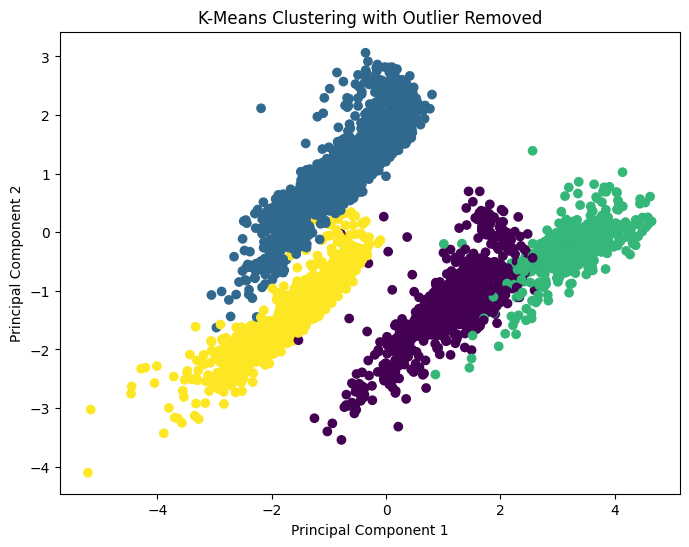

In [176]:
#visual using PCA
pca = PCA(n_components=4)
#data_pca = pca.fit_transform(new_exoplanets_filtered_KMeans_scaled)
data_pca = pca.fit_transform(new_exoplanets_filtered_KMeans_cleaned)

# Now use kmeans_labels (which holds the cluster assignments) for coloring the scatter plot
plt.figure(figsize=(8,6))
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=kmeans_labels)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clustering with Outlier Removed')
plt.show()

Compared to the K Means clustering model #1, the PCA graph displays 4 distinct clusters though there is slight overlap between the green and purple clusters. These clusters are elongated elipses rather than circular clusters. These observations align with the improved silhouette score.

In [177]:
# seeing how accurate our model was at clustering
kmeans_score = silhouette_score(new_exoplanets_filtered_KMeans_cleaned, kmeans_labels)
print("Silhouette Score for K-Means Clustering: ", kmeans_score)

Silhouette Score for K-Means Clustering:  0.483204086193876


Compared to the K Means clustering model #1, the silhouette score improved with a new score of 0.483 which implies moderately strong structure. This means the clusters are seperated with minor overlap.

In [178]:
# interpreting centroid cluster values to interpret planetary system
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(new_exoplanets_filtered_KMeans_cleaned)

# Get column names BEFORE scaling
feature_columns = new_exoplanets_filtered_KMeans.columns

# Inverse transform cluster centers back to original scale
cluster_centers_original = scaler.inverse_transform(kmeans.cluster_centers_)

# Convert to DataFrame
cluster_centers_df = pd.DataFrame(
    cluster_centers_original,
    columns=feature_columns
)

cluster_centers_transposed_outlier_rem = cluster_centers_df.T
cluster_centers_transposed_outlier_rem

,0,1,2,3
star_number_per_system,1.095279e+00,1.071338e+00,1.120690e+00,1.110609e+00
orbital_period_day,4.771322e-01,5.035295e-01,4.779011e+01,2.991750e-01
orbit_semi_major_axis_au,8.637167e-01,3.349949e-01,2.790099e+00,2.963937e-01
planet_rad_earth_rad,4.569505e+00,5.767885e+00,3.593716e+00,7.268093e+00
planet_mass_earth_mass,1.287442e+02,1.619505e+02,1.064973e+02,2.501898e+02
planet_equil_temp_k,2.881480e+00,3.412384e+00,1.901706e+00,4.198891e+00
stellar_effective_temp_k,8.188553e-01,9.811414e-01,6.120418e-01,1.076419e+00
stellar_rad_solar_rad,7.871245e-01,1.062207e+00,4.078980e-01,1.351731e+00
stellar_mass_solar_mass,7.534019e-01,9.844791e-01,4.023816e-01,1.192122e+00
stellar_surf_grav,4.565775e+00,4.393432e+00,4.839425e+00,4.266253e+00


Similarly to the K Means Model #1 results, after removing 535 exoplanets identifed as outleir, the dominant features which differentiated each cluster reamined as the spectral type which is based on star type and the star evolutionary stage. All other stellar parameters were able to effectively seperate clusters. However, unlike the K MEans Model #1, all planetary features were not able to accurately seperate clusters due to the high variability within planetary features. The K Means clustering model independently grouped clusters where:
* Cluster 0: Type K Main Sequence Star Planetary system
* Cluster 1: Sun-Like Planetary System
* Cluster 2: Red Dwarf Planetary System
* Cluster 3: Type F Main Sequence Star Planetary system

In [179]:
# renaming the clusters based on the interpretation
cluster_centers_transposed_outlier_rem.columns = [
    "Type K Main Sequence Star Planetary system",
    "Sun-Like Planetary System",
    "Red Dwarf Planetary System",
    "Type F Main Sequence Star Planetary system"
]

cluster_centers_transposed_outlier_rem

,Type K Main Sequence Star Planetary system,Sun-Like Planetary System,Red Dwarf Planetary System,Type F Main Sequence Star Planetary system
star_number_per_system,1.095279e+00,1.071338e+00,1.120690e+00,1.110609e+00
orbital_period_day,4.771322e-01,5.035295e-01,4.779011e+01,2.991750e-01
orbit_semi_major_axis_au,8.637167e-01,3.349949e-01,2.790099e+00,2.963937e-01
planet_rad_earth_rad,4.569505e+00,5.767885e+00,3.593716e+00,7.268093e+00
planet_mass_earth_mass,1.287442e+02,1.619505e+02,1.064973e+02,2.501898e+02
planet_equil_temp_k,2.881480e+00,3.412384e+00,1.901706e+00,4.198891e+00
stellar_effective_temp_k,8.188553e-01,9.811414e-01,6.120418e-01,1.076419e+00
stellar_rad_solar_rad,7.871245e-01,1.062207e+00,4.078980e-01,1.351731e+00
stellar_mass_solar_mass,7.534019e-01,9.844791e-01,4.023816e-01,1.192122e+00
stellar_surf_grav,4.565775e+00,4.393432e+00,4.839425e+00,4.266253e+00


In [180]:
cluster_names_cleaned = {
    0: "Type K Main Sequence Star Planetary system",
    1: "Sun-Like Planetary System",
    2: "Red Dwarf Planetary System",
    3: "Type F Main Sequence Star Planetary system"
}

# predicting which clusters the top 20 Earth Like exoplanets belong to

# standardizing top 20 Earth-Like plansts list from the manhattan distance KNN model
closest_planets_man_list_cleaned = scaler.transform(closest_planets_man_list)
# standardizing top 20 Earth-Like plansts list from the euclidean distance KNN model
closest_planets_euc_list_cleaned = scaler.transform(closest_planets_euc_list)

# Predict the cluster for the top 20 Earth Like exoplanets using K-Means
predict_cluster_man_cleaned = kmeans_pipeline.predict(closest_planets_man_list_cleaned)
predict_cluster_euc_cleaned = kmeans_pipeline.predict(closest_planets_euc_list_cleaned)

# Print results
print("Top 20 Earth-Like Exoplanets using Manhattan Distance (KNN Model #1 Results):")
for i in range(20):
    cluster_id = predict_cluster_man_cleaned[i]
    print(f"{i+1}. {closest_planets_man[i]} (Cluster: {cluster_names_cleaned[cluster_id]})")

print("\nTop 20 Earth-Like Exoplanets using Euclidean Distance (KNN Model #2 Results):")
for i in range(20):
    cluster_id = predict_cluster_euc_cleaned[i]
    print(f"{i+1}. {closest_planets_euc[i]} (Cluster: {cluster_names_cleaned[cluster_id]})")

Top 20 Earth-Like Exoplanets using Manhattan Distance (KNN Model #1 Results):
1. Kepler-452 b (Cluster: Sun-Like Planetary System)
2. Kepler-1638 b (Cluster: Sun-Like Planetary System)
3. Kepler-51 e (Cluster: Sun-Like Planetary System)
4. Kepler-1606 b (Cluster: Sun-Like Planetary System)
5. Kepler-1701 b (Cluster: Sun-Like Planetary System)
6. Kepler-22 b (Cluster: Sun-Like Planetary System)
7. Kepler-1126 c (Cluster: Sun-Like Planetary System)
8. Kepler-1549 b (Cluster: Sun-Like Planetary System)
9. Kepler-1690 b (Cluster: Sun-Like Planetary System)
10. Kepler-69 c (Cluster: Sun-Like Planetary System)
11. Kepler-1090 b (Cluster: Sun-Like Planetary System)
12. Kepler-1634 b (Cluster: Sun-Like Planetary System)
13. Kepler-1185 b (Cluster: Sun-Like Planetary System)
14. Kepler-311 d (Cluster: Sun-Like Planetary System)
15. Kepler-132 e (Cluster: Sun-Like Planetary System)
16. Kepler-442 b (Cluster: Type K Main Sequence Star Planetary system)
17. Kepler-1554 b (Cluster: Sun-Like Planeta

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [181]:
# viewing in table form
results_man_cleaned = pd.DataFrame({
    "Planet": closest_planets_man,
    "Cluster_ID": predict_cluster_man_cleaned
})

results_euc_cleaned = pd.DataFrame({
    "Planet": closest_planets_euc,
    "Cluster_ID": predict_cluster_euc_cleaned
})

# map cluster names
results_man_cleaned["Cluster_Type"] = results_man_cleaned["Cluster_ID"].map(cluster_names_cleaned)
results_euc_cleaned["Cluster_Type"] = results_euc_cleaned["Cluster_ID"].map(cluster_names_cleaned)

print("Top 20 Earth-Like Exoplanets using Manhattan Distance (KNN Model #1 Results):\n")
print(results_man_cleaned)
print("\nTop 20 Earth-Like Exoplanets using Euclidean Distance (KNN Model #2 Results):\n")
print(results_euc_cleaned)

Top 20 Earth-Like Exoplanets using Manhattan Distance (KNN Model #1 Results):

           Planet  Cluster_ID                                Cluster_Type
0    Kepler-452 b           1                   Sun-Like Planetary System
1   Kepler-1638 b           1                   Sun-Like Planetary System
2     Kepler-51 e           1                   Sun-Like Planetary System
3   Kepler-1606 b           1                   Sun-Like Planetary System
4   Kepler-1701 b           1                   Sun-Like Planetary System
5     Kepler-22 b           1                   Sun-Like Planetary System
6   Kepler-1126 c           1                   Sun-Like Planetary System
7   Kepler-1549 b           1                   Sun-Like Planetary System
8   Kepler-1690 b           1                   Sun-Like Planetary System
9     Kepler-69 c           1                   Sun-Like Planetary System
10  Kepler-1090 b           1                   Sun-Like Planetary System
11  Kepler-1634 b           1    

Similar to the results from the K Means model #1, the model was able to correctly predict the planetary system the top 20 Earth-analogus exoplanets identified by both KNN models based on the spectral type of their hsot stars. Overall, the model was accurate in predicting that a majority of the top-20 most Earth Like exoplanets from both KNN models correctly belong to a Sun-Like planetary system. Thus, ensuring model robustness.

Based on the limitations of the model to differentiate clusters based on all planetary features due the feature variabiltiy, both K Means cluster models are unable to idenfity the natural grouping of exoplanets based on what type of planet the exoplanets are. However, both models are able to naturally and correctly group exoplanets into planetary systems based on the type of host star they orbit.

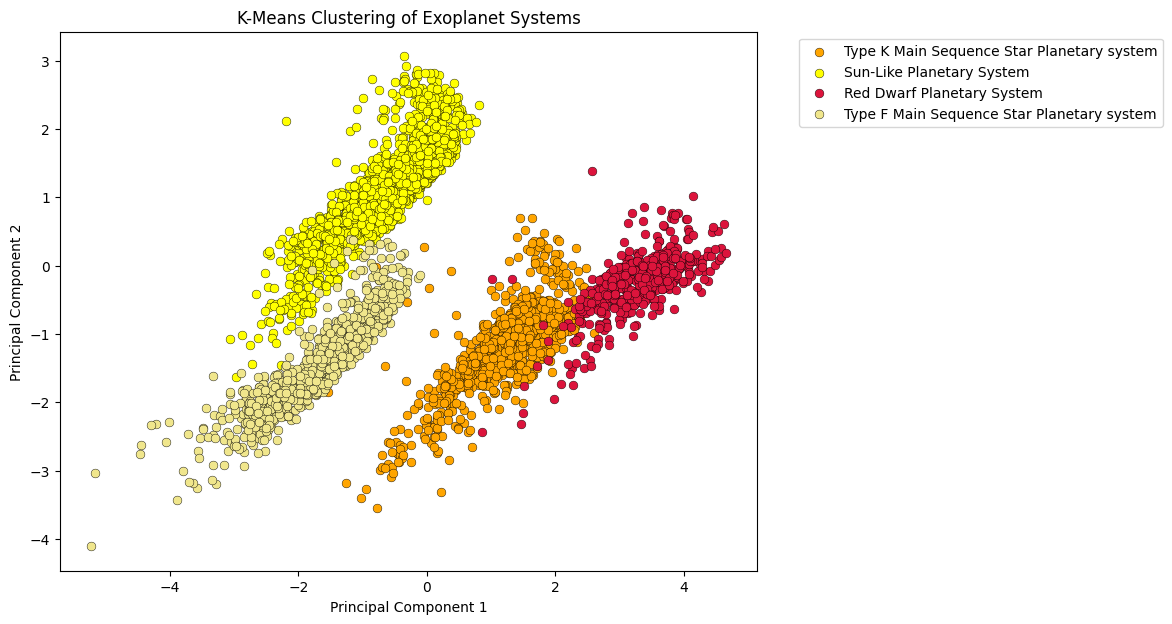

In [182]:
# rerunning PCA visualization with clusters labeled

# define cluster colors
cluster_colors_cleaned = {
    0: "orange",
    1: "yellow",
    2: "crimson",
    3: "khaki"
}

# visualize using PCA
pca = PCA(n_components=4)
data_pca = pca.fit_transform(new_exoplanets_filtered_KMeans_cleaned)

plt.figure(figsize=(9,7))

for cluster_id in range(4):

    # select points in this cluster
    cluster_points = data_pca[kmeans_labels == cluster_id]

    plt.scatter(
        cluster_points[:,0],
        cluster_points[:,1],
        color=cluster_colors_cleaned[cluster_id],
        label=cluster_names_cleaned[cluster_id],
        marker='o',
        s=40,
        edgecolors='black',
        linewidths=0.3,
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering of Exoplanet Systems")

plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()

---
## **Unsupervised Learning - Guassian Mixture Model (GMM)**
To potentially improve upon the K Means cluster model to identify the natural groupings of exoplanets, GMM will be used to serve as a clustering model.

GMM does not assume spherical clusters nor does it assume all clusters have the same shape. These assumptions can be fine tuned based on the covariance type selcted. GMM allows for more flexibiltiy for elliptical clusters or clusters which exhbiit variation in shape.

GMM forms probabilistic clusters. GMM assumes that data is generated from a finite mixture of k distinct Gaussian distributions, each representing a cluster with its own mean, covariance, and mixing weight. Therefore, the clusters are assumed to be elliptical.

This may potentially work well for exoplanet data where mass-radius relationships are continuous and exoplanet populations overlap.

Similar to the K Means models #1 and #2, there will be 2 GMM models created where one will use encoded and scaled features with outliers kept. While the second GMM model will use encoded and scaled features with otuliers removed.

#### **Preparing Dataset for Unsupervised Learning using Guassian Mixture Model for Clustering and Unsupervised Learning using PCA Visualization**

In [183]:
# import Gaussian Mixture Model
from sklearn.mixture import GaussianMixture
from sklearn.mixture import GaussianMixture
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

In [184]:
# making a copy of the scaled K Means dataset to use for the GMM model
new_exoplanets_filtered_GMM = new_exoplanets_filtered_KMeans.copy()
new_exoplanets_filtered_GMM_scaled = new_exoplanets_filtered_KMeans_scaled.copy()
new_exoplanets_filtered_GMM_cleaned = new_exoplanets_filtered_KMeans_cleaned.copy()

---
#### **Covariance Types in GMM**

**1) 'Full' (most flexible)**
* Each cluster has its own full covariance matrix.
* Meaning:
  * Clusters can have different shapes
  * Different sizes
  * Different orientations
* Example shapes:
  * Tall ellipse
  * Wide ellipse
  * Rotated ellipse
* Advantages:
  * Most realistic for complex data
  * Best when features are correlated
* Disadvantages:
  * Slower
  * More parameters
* Best suited for high dimensional astrophysical data, this is often a good choice.

---
**2) 'tied'**
* All clusters share one covariance matrix.
* Meaning:
  * Clusters can still be elliptical
  * But they must all have the same shape and orientation
* Example shapes:
  * Same ellipse shape
  * Just shifted to different locations
* Advantages:
  * Fewer parameters
  * More stable
* Disadvantage:
  * Less flexible due to the same shape constraint

---
**3) 'diag'**
* Each cluster has its own diagonal covariance matrix.
* Meaning:
  * Features are assumed independent
  * Clusters are axis-aligned ellipses
* Meaning:
  * Custers can be wider in some features but cannot rotate
* Example shapes:
  * ellipse aligned with x/y axes only.
* Advantages:
  * Faster
  * Less parameters
* Disadvantage:
  * Cannot model correlated variables

---

**4) spherical (most restrictive)**
* Each cluster is a sphere.
* Meaning:
  * All directions have the same variance
  * Equivalent to a circle in 2D
* Example shapes:
  * perfect circles
  * different radii
* Advantages:
  * Very fast
  * Very few parameters
* Disadvantages:
  * Often unrealistic.
* This is closest to K-Means behavior.

---

### **Guassiam Mixture Model #1 (With One Hot Encoding on Categorical Features + Standard Scaling on all Features + Outliers Not Removed)**

In [185]:
# Define GMM using a covariance type = full
gmm = GaussianMixture(n_components=9, covariance_type='full', random_state=42)

# Fit model
gmm_labels = gmm.fit_predict(new_exoplanets_filtered_GMM_scaled)

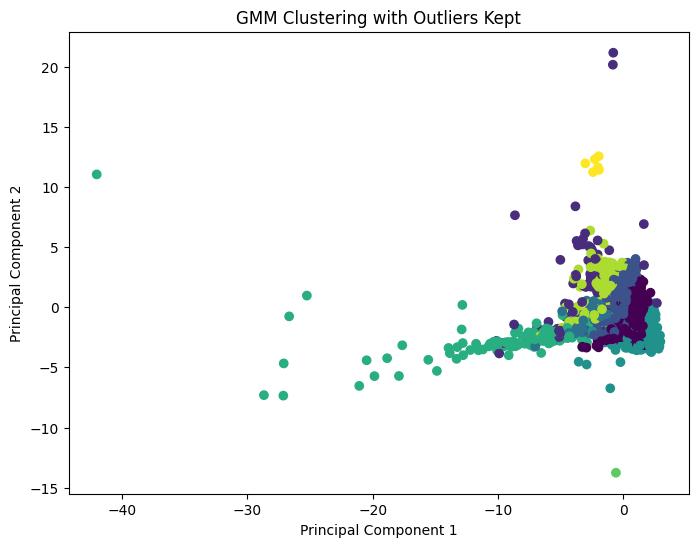

In [186]:
# Visualize the GMM model using PCA
pca = PCA(n_components=2)
data_pca = pca.fit_transform(new_exoplanets_filtered_GMM_scaled)

plt.figure(figsize=(8,6))
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=gmm_labels)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("GMM Clustering with Outliers Kept")
plt.show()

Unlike the K Means Model #1 which used 6 clusters, GMM Model #1 uses 9 clusters. By increasing the number of clusters, the clusters show slightly greater seperation, particularly within the yellow cluster. However, there is still major overlapping among the clusters and the outlier planets still show to distort clustering.

----
**Akaike Information Criterion (AIC)**

AIC=2k−2ln(L)

where:
* k = number of model parameters
* L = likelihood of the model

----
**Bayesian Information Criterion (BIC):**

BIC=ln(n)k−2ln(L)

where:
* n = number of data points
* k = number of parameters
* L = likelihood

----

In [187]:
# Evaluating GMM using Silhouette score
gmm_score = silhouette_score(new_exoplanets_filtered_GMM_scaled, gmm_labels)
print("Silhouette Score for GMM:", gmm_score)

# Evaluating GMM using AIC (Akaike Information Criterion)
gmm_aic_score = gmm.aic(new_exoplanets_filtered_GMM_scaled)
print("AIC (Akaike Information Criterion) for GMM:", gmm_aic_score)

# Evaluating GMM using BIC (Bayesian Information Criterion)
gmm_bic_score = gmm.bic(new_exoplanets_filtered_GMM_scaled)
print("BIC (Bayesian Information Criterion) for GMM:", gmm_bic_score)

Silhouette Score for GMM: 0.4198092080667522
AIC (Akaike Information Criterion) for GMM: -1345293.7298002942
BIC (Bayesian Information Criterion) for GMM: -1307891.5579834098


A silhouette score of about 0.42 indicates moderate cluster separation. This was better than the K Means cister model silhouette score of 0.401. The GMM model #1 silhouette  score suggests that the clustering structure captured by the GMM is reasonably distinct and meaningful but somewhat overlapping, which matches what we see in the PCA visualization where clusters overlap in the central region.

This is fairly typical for astrophysical datasets, where planetary properties often vary along continuous distributions rather than forming perfectly separated groups.

The Akaike Information Criterion (AIC) evaluates the quality of a statistical model by balancing Model fit (how well the model explains the data) and Model complexity (number of parameters). Where a lower AIC values indicate a better model.

The Bayesian Information Criterion (BIC) is similar to AIC but penalizes model complexity more strongly. SImailr to the AIC, the lower BIC values indicate a better model. However, unlike the AIC, BIC penalizes complexity more than AIC, it often favors simpler models with fewer clusters.

The large negative values for the AIC and BIC scores imply the GMM model #1 fits the data well relative to its complexity. This supports the presence of several overlapping but meaningful groupings within the exoplanet dataset.

Note: AIC and BIC are only meaningful when comparing this score to another AIC or BIC score from another GMM model using the same scaled data.

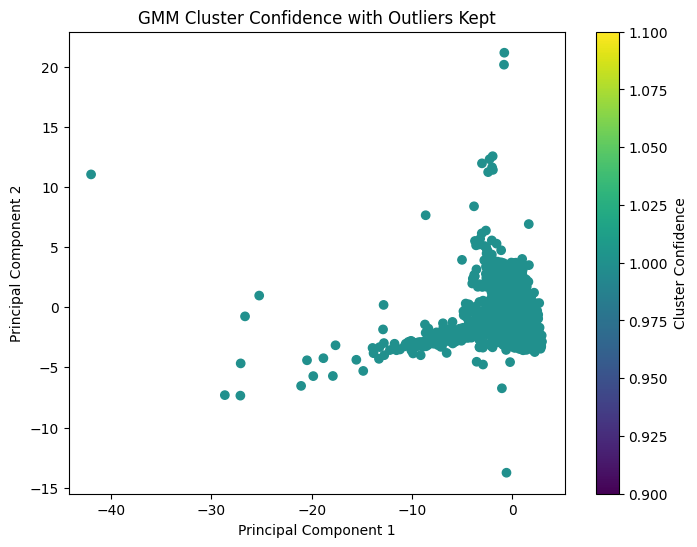

In [188]:
# Get membership probabilities
probabilities = gmm.predict_proba(new_exoplanets_filtered_GMM_scaled)

# Get maximum probability per planet
max_probs = np.max(probabilities, axis=1)

plt.figure(figsize=(8,6))
scatter = plt.scatter(
    data_pca[:, 0],
    data_pca[:, 1],
    c=max_probs,
    vmin=0.9,
    vmax=1.1
)
plt.colorbar(scatter, label="Cluster Confidence")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("GMM Cluster Confidence with Outliers Kept")
plt.show()

GMM has the ability to display how confident the model was in assigning exoplanets to a particular cluster.

Note for Interpretation:
* Value close to 1.0 --> planet clearly belongs to one cluster
* Value closer to 0.5–0.7 --> planet lies between clusters

Based on the graph, each exoplanet has a high probability of belonging to the correct cluster. Therefore, the GMM is very confident about cluster membership Most planets have >99% probability of belonging to their assigned cluster. This implies that though GMM allows overlapping distributions, the data itself may not overlap much.

Given that the PCA graph showed major overlapping but the probability was so high, this could imply that because 34 features were compressed into a 2D featrue space, the clusters appeared to overlap but in other PCA axes, there may be actual distinction present.

In [189]:
# To verify strong probabilistic membership print
print("minimum prob:", max_probs.min())
print("maximum prob:", max_probs.max())
print("percentiles:", np.percentile(max_probs, [5,25,50,75,95]))

minimum prob: 0.9829193728702762
maximum prob: 1.0
percentiles: [1. 1. 1. 1. 1.]


Interpretation:
* Minimum probability: 0.9829 --> The least certain planet still has 98.3% probability of belonging to its cluster
* Maximum probability: 1.0 --> Some planets are assigned with 100% confidence
* Percentiles: [1. 1. 1. 1. 1.] --> Almost all planets have ≈100% membership probability

Therefore, nearly every planet is overwhelmingly assigned to a single cluster. So, clusters are extremely well separated in the feature space used by GMM. Even with outliers included, the algorithm sees clear boundaries between planetary populations. So, planets fall naturally into distinct groups.

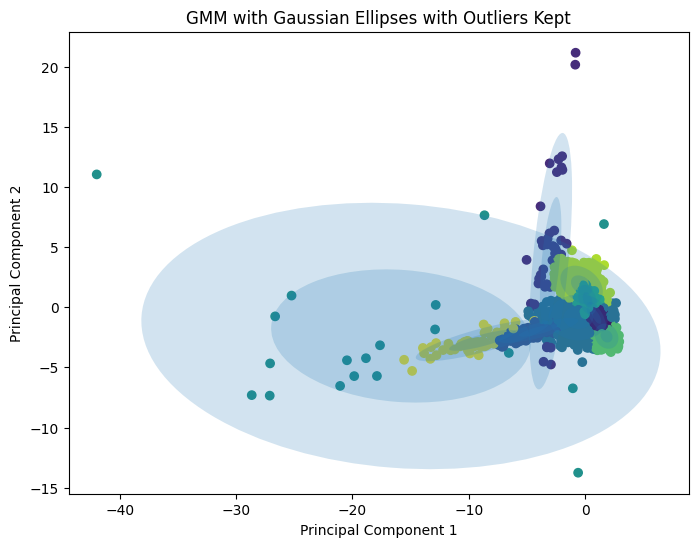

In [190]:
def draw_ellipse(position, covariance, ax=None, **kwargs):
    ax = ax or plt.gca()

    if covariance.shape == (2, 2):
        U, s, Vt = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2 * np.sqrt(s)
    else:
        angle = 0
        width, height = 2 * np.sqrt(covariance)

    for nsig in range(1, 3):
        ax.add_patch(Ellipse(position, nsig*width, nsig*height,
                             angle=angle, **kwargs))

# Fit PCA again (2D)
pca = PCA(n_components=2)
data_pca = pca.fit_transform(new_exoplanets_filtered_GMM_scaled)

# Fit GMM on PCA-reduced data
gmm_2d = GaussianMixture(n_components=9, covariance_type='full', random_state=42)
gmm_2d.fit(data_pca)

labels = gmm_2d.predict(data_pca)

plt.figure(figsize=(8,6))
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=labels)

for pos, covar in zip(gmm_2d.means_, gmm_2d.covariances_):
    draw_ellipse(pos, covar, alpha=0.2)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("GMM with Gaussian Ellipses with Outliers Kept")
plt.show()

The graph shows the exoplanet dataset projected onto the first two Principal Components (PC1 and PC2) using Principal Component Analysis (PCA). PCA reduces the high-dimensional feature space of the exoplanet data into two dimensions while preserving as much variance as possible. Each point represents an individual exoplanet, and the colors indicate the cluster assignments predicted by the Gaussian Mixture Model (GMM).

Gaussian ellipses are drawn around each cluster to represent the covariance structure of the Gaussian distributions learned by the GMM. These ellipses illustrate the direction and spread of each cluster, showing how the model believes the data is distributed in the reduced space.

The visualization shows that most exoplanets form a dense concentration near the center of the plot, indicating that many planets share similar characteristics in terms of the variables used for clustering. Several clusters overlap in this central region, suggesting that some groups of planets have similar feature distributions and are not completely separable in two dimensions.

A number of points appear far from the central clusters, particularly along the negative direction of Principal Component 1. These represent outliers or rare planetary types whose properties differ significantly from the majority of planets in the dataset. Because these outliers have large variance, some Gaussian ellipses appear stretched or very large, reflecting the model’s attempt to capture these dispersed points within a Gaussian distribution.

Overall, the PCA projection with GMM ellipses reveals that while the dataset contains several identifiable clusters of exoplanets, there is also substantial overlap between groups and the presence of extreme planetary systems that lie outside the main distribution.

In [191]:
# interpreting centroid cluster values to interpret planetary system
gmm = GaussianMixture(n_components=9, covariance_type='full', random_state=42)
gmm.fit(new_exoplanets_filtered_GMM_scaled)

# Get column names BEFORE scaling
feature_columns = new_exoplanets_filtered_GMM.columns

# Create a DataFrame of GMM cluster means
gmm_cluster_centers_df = pd.DataFrame(
    gmm.means_,
    columns=feature_columns)

cluster_centers_transposed_gmm = gmm_cluster_centers_df.T
cluster_centers_transposed_gmm

,0,1,2,3,4,5,6,7,8
star_number_per_system,-0.001040,0.408259,-0.076639,0.148501,0.072674,0.011140,-0.291421,0.051190,2.244242
orbital_period_day,-0.013874,-0.013523,-0.013883,-0.013795,-0.010735,-0.013519,73.592339,-0.013881,-0.013450
orbit_semi_major_axis_au,-0.005419,0.037447,-0.024243,-0.015078,0.000508,0.012704,70.945631,-0.016432,-0.004003
planet_rad_earth_rad,-0.261589,1.017490,-0.141055,1.066660,-0.322900,2.714464,0.547247,0.059358,1.803673
planet_mass_earth_mass,-0.170813,0.975855,-0.148645,0.435318,-0.135137,2.146487,2.365985,0.038101,0.711591
planet_equil_temp_k,-0.251504,0.787873,0.079518,-0.382542,-0.724465,-0.637582,-0.834342,0.508730,-0.653949
stellar_effective_temp_k,-0.514582,0.894304,0.219926,-0.336044,-1.428264,-0.352092,-1.521197,0.648399,19.440284
stellar_rad_solar_rad,-0.198729,0.362555,-0.116961,0.638525,-0.280204,3.322573,-0.285170,-0.037287,-0.335943
stellar_mass_solar_mass,-0.551305,1.246171,0.061852,0.880823,-1.445872,2.082229,-1.528233,0.615646,-1.251852
stellar_surf_grav,0.463853,-0.956669,0.049128,-2.086166,1.053246,-3.597759,1.031706,-0.254904,2.714460


Note for Interpretation:

Since your data was scaled (probably standard scaling: mean=0, std=1):
  * Values around 0 --> feature is near the dataset mean for that cluster.
  * Values > 0 --> feature is higher than average in this cluster.
  * Values < 0 --> feature is lower than average in this cluster.

---
**Cluster 0: Type K Main Sequence stars hosting small rocky planets**

Orbital properties:
* orbital_period_day slightly shorter than average
* orbit_semi_major_axis_au slightly smaller orbits

Planet properties:
* planet_rad_earth_rad smaller planets
* planet_mass_earth_mass slightly less massive
* planet_equil_temp_k slightly cooler planets

Host star properties:
* stellar_effective_temp_k cooler stars
* stellar_rad_solar_rad slightly smaller stars
* stellar_mass_solar_mass lower stellar mass
* stellar_surf_grav higher surface gravity
* stellar_luminosity_solar_lum slightly dimmer

Orbital dynamics:
* planet_orbital_velocity slightly higher

Habitability:
* habitable_zone_main_seq slightly higher than average

Spectral type:
* Strong signal for KV stars

Interpretation:
* Small planets orbiting cool Type K Main Sequence stars in fairly typical compact systems for a KV star system.

---
**Cluster 1: Hot main sequence and evolved subgiants/giants hosting large massive planets**

Orbital properties:
* Slightly shorter orbital periods
* Slightly larger orbital distance

Planet properties:
* Large radius planets
* Massive planets
* Very warm equilibrium temperatures

Host star properties:
* Hot stars
* Larger stellar radii
* Higher stellar mass
* Lower surface gravity
* Slightly brighter luminosity

Orbital dynamics:
* Average orbital velocity

Habitability:
* habitablilty slightly lower than average

Spectral type:
* Strong signals for
  * AV
  * FIV
  * GIV
  * GIII
  * BV
  * White dwarfs present

Interpretation:
* large massive planets orbiting hot large B and A main sequence stars, F and G subgaints, and G giants in a slightly compact system.

---
**Cluster 2: Sun-like stars hosting Earth-sized and Super-Earth-sized rocky planets**

Orbital properties:
* Average orbital distances and periods

Planet properties:
* Averge to slightly smaller planets
* Averge to slightly less massive planets
* Near-average equilibrium temperature

Host star properties:
* Slightly hotter stars
* Average stellar size
* Average stellar mass
* Normal surface gravity

Orbital dynamics:
* Average orbital velocity

Habitability:
* Average habitability

Spectral type:
* Dominated by GV stars

Interpretation:
* This cluster resembles Solar-type systems, with planets similar to Earth's size and mass around Sun-like G-type main sequence stars.

---
**Cluster 3: Type K Subgiants hosting large gaseous planets**

Orbital properties:
* Slightly smaller orbital radii
* Average orbital distance

Planet properties:
* Large planetary radius
* Moderately massive planets
* Cooler equilibrium temperatures

Host star properties:
* Slightly cooler stars
* Large stellar radius
* High stellar mass
* Very low surface gravity

Habitability:
* habitablilty slightly lower than average

Orbital dynamics:
* Lower orbital velocity

Spectral type:
* Strong K IV (subgiant) signal

Interpretation:
* Large less dense (potenitally gaseous) planets orbiting evolved K-type subgiant stars.

---
**Cluster 4: Cool Red dwarfs hosting small rocky planets**

Orbital properties:
* Average orbital distance
* Slightly shorter periods

Planet properties:
* Small planets
* Slightly lower masses
* Very cool equilibrium temperatures

Host star properties:
* Very cool stars
* Small stellar radii
* Low stellar masses
* High surface gravity
* Low luminosity

Habitability:
* habitablilty slightly lower than average

Spectral type:
* Strong MV red dwarf signal

Interpretation:
* Small planets orbitting cool red dwarf (Type M Main sequence) stars.

---
**Cluster 5: Evolved giants hosting large massive planets**

Orbital properties:
* Slightly larger orbits
* Near average orbital distance

Planet properties:
* Very large planets
* Very massive planets
* Cool equilibrium temperatures

Host star properties:
* Large stellar radii
* High stellar masses
* Very low surface gravity
* High stellar luminosity

Spectral type:
* KIII giant stars
* Some B IV
* Some M III

Interpretation:
* Massive planets orbiting evolved giant stars, especially K-giants.

---
**Cluster 6: Wide orbit red dwarfs hosting massive dense planets (outlier cluster)**

Orbital properties:
* Extremely long orbital periods
* Very large orbital distance

Planet properties:
* Moderately large planets
* Massive planets
* Very cool equilibrium temperatures

Host star properties:
* Very cool temperature stars
* Lower stellar mass
* Normal surface gravity

Spectral type:
* Mix of Type M main sequence stars (red dwarfs)

Interpretation:
* Planets on very wide orbits, likely long-period systems.

---
**Cluster 7: Type F Main sequence stars hosting warm Super-Earth-sized planets**

Orbital properties:
* Short orbital periods
* Near average orbital distance

Planet properties:
* Averge to slightly larger planets
* Averge to slightly more massive planets
* Warm equilibrium temperatures

Host star properties:
* Hot temperature stars
* Slightly larger stellar radii
* Slightly higher stellar mass
* Slightly lower surface gravity

Spectral type:
* Dominated by F main sequence stars
* Some A-type main sequence stars

Interpretation:
* Warm planets orbiting hotter F-type main-sequence stars.

---
**Cluster 8: Extremely hot binary subdwarf B stars hosting large planets (rare outlier cluster)**

Star system structure:
* Extremely high stars per system (artifact/outlier)

Orbital properties:
* Average orbital periods

Planet properties:
* Very large planets
* Moderately massive planets
* Cooler equilibrium temperatures

Host star properties:
* Extremely hot stars
* Small stellar radii
* Low stellar masses
* Very high surface gravity

Spectral type:
* Dominated by sdB (hot subdwarf) stars

Interpretation:
* Rare hot subdwarf stellar systems, likely astrophysical outliers.

---

In [192]:
# renaming the clusters based on the interpretation
cluster_centers_transposed_gmm.columns = [
    "Type K Main Sequence stars hosting small rocky planets",
    "Hot main sequence and evolved subgiants/giants hosting large massive planets",
    "Sun-like stars hosting Earth-sized and Super-Earth-sized rocky planets",
    "Type K Subgiants hosting large gaseous planets",
    "Cool Red dwarfs hosting small rocky planets",
    "Evolved giants hosting giant planets",
    "Wide orbit red dwarfs hosting massive dense planets",
    "Type F Main sequence stars hosting warm Super-Earth-sized planets",
    "Extremely hot binary subdwarf B stars hosting large planets"
]

cluster_centers_transposed_gmm

,Type K Main Sequence stars hosting small rocky planets,Hot main sequence and evolved subgiants/giants hosting large massive planets,Sun-like stars hosting Earth-sized and Super-Earth-sized rocky planets,Type K Subgiants hosting large gaseous planets,Cool Red dwarfs hosting small rocky planets,Evolved giants hosting giant planets,Wide orbit red dwarfs hosting massive dense planets,Type F Main sequence stars hosting warm Super-Earth-sized planets,Extremely hot binary subdwarf B stars hosting large planets
star_number_per_system,-0.001040,0.408259,-0.076639,0.148501,0.072674,0.011140,-0.291421,0.051190,2.244242
orbital_period_day,-0.013874,-0.013523,-0.013883,-0.013795,-0.010735,-0.013519,73.592339,-0.013881,-0.013450
orbit_semi_major_axis_au,-0.005419,0.037447,-0.024243,-0.015078,0.000508,0.012704,70.945631,-0.016432,-0.004003
planet_rad_earth_rad,-0.261589,1.017490,-0.141055,1.066660,-0.322900,2.714464,0.547247,0.059358,1.803673
planet_mass_earth_mass,-0.170813,0.975855,-0.148645,0.435318,-0.135137,2.146487,2.365985,0.038101,0.711591
planet_equil_temp_k,-0.251504,0.787873,0.079518,-0.382542,-0.724465,-0.637582,-0.834342,0.508730,-0.653949
stellar_effective_temp_k,-0.514582,0.894304,0.219926,-0.336044,-1.428264,-0.352092,-1.521197,0.648399,19.440284
stellar_rad_solar_rad,-0.198729,0.362555,-0.116961,0.638525,-0.280204,3.322573,-0.285170,-0.037287,-0.335943
stellar_mass_solar_mass,-0.551305,1.246171,0.061852,0.880823,-1.445872,2.082229,-1.528233,0.615646,-1.251852
stellar_surf_grav,0.463853,-0.956669,0.049128,-2.086166,1.053246,-3.597759,1.031706,-0.254904,2.714460


In [193]:
cluster_names_gmm = {
    0: "Type K Main Sequence stars hosting small rocky planets",
    1: "Hot main sequence and evolved subgiants/giants hosting large massive planets",
    2: "Sun-like stars hosting Earth-sized and Super-Earth-sized rocky planets",
    3: "Type K Subgiants hosting large gaseous planets",
    4: "Cool Red dwarfs hosting small rocky planets",
    5: "Evolved giants hosting giant planets",
    6: "Wide orbit red dwarfs hosting massive dense planets",
    7: "Type F Main sequence stars hosting warm Super-Earth-sized planets",
    8: "Extremely hot binary subdwarf B stars hosting large planets"
}

# predicting which clusters the top 20 Earth Like exoplanets belong to

# Get the feature rows directly from the original dataset
closest_planets_man_df = new_exoplanets_filtered_GMM.loc[closest_planets_man]
closest_planets_euc_df = new_exoplanets_filtered_GMM.loc[closest_planets_euc]

# Ensure feature order matches training data
closest_planets_man_df = closest_planets_man_df[new_exoplanets_filtered_GMM.columns]
closest_planets_euc_df = closest_planets_euc_df[new_exoplanets_filtered_GMM.columns]

# Scale features using the same scaler used for training
closest_planets_man_scaled = scaler.transform(closest_planets_man_df)
closest_planets_euc_scaled = scaler.transform(closest_planets_euc_df)

# Predict clusters
predict_cluster_man = gmm.predict(closest_planets_man_scaled)
predict_cluster_euc = gmm.predict(closest_planets_euc_scaled)

# Print Manhattan results
print("Top Earth-Like Exoplanets using Manhattan Distance (KNN Model #1 Results):")

for i, planet in enumerate(closest_planets_man):
    cluster_id = predict_cluster_man[i]
    cluster_name = cluster_names_gmm.get(cluster_id, "Unknown Cluster")
    print(f"{i+1}. {planet} (Cluster {cluster_id}: {cluster_name})")

# Print Euclidean results
print("\nTop Earth-Like Exoplanets using Euclidean Distance (KNN Model #2 Results):")

for i, planet in enumerate(closest_planets_euc):
    cluster_id = predict_cluster_euc[i]
    cluster_name = cluster_names_gmm.get(cluster_id, "Unknown Cluster")
    print(f"{i+1}. {planet} (Cluster {cluster_id}: {cluster_name})")

Top Earth-Like Exoplanets using Manhattan Distance (KNN Model #1 Results):
1. Kepler-452 b (Cluster 2: Sun-like stars hosting Earth-sized and Super-Earth-sized rocky planets)
2. Kepler-1638 b (Cluster 2: Sun-like stars hosting Earth-sized and Super-Earth-sized rocky planets)
3. Kepler-51 e (Cluster 2: Sun-like stars hosting Earth-sized and Super-Earth-sized rocky planets)
4. Kepler-1606 b (Cluster 2: Sun-like stars hosting Earth-sized and Super-Earth-sized rocky planets)
5. Kepler-1701 b (Cluster 2: Sun-like stars hosting Earth-sized and Super-Earth-sized rocky planets)
6. Kepler-22 b (Cluster 2: Sun-like stars hosting Earth-sized and Super-Earth-sized rocky planets)
7. Kepler-1126 c (Cluster 2: Sun-like stars hosting Earth-sized and Super-Earth-sized rocky planets)
8. Kepler-1549 b (Cluster 2: Sun-like stars hosting Earth-sized and Super-Earth-sized rocky planets)
9. Kepler-1690 b (Cluster 2: Sun-like stars hosting Earth-sized and Super-Earth-sized rocky planets)
10. Kepler-69 c (Clus

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(


In [194]:
# verifying accuracy of results by viewing the probability of each cluster for KNN manahattan distance
proba_df_man = pd.DataFrame(
    gmm.predict_proba(closest_planets_man_scaled),
    columns=[f"Cluster_{i}" for i in range(gmm.n_components)],
    index=closest_planets_man
)

proba_df_man

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(


,Cluster_0,Cluster_1,Cluster_2,Cluster_3,Cluster_4,Cluster_5,Cluster_6,Cluster_7,Cluster_8
Kepler-452 b,0.0,0.0,1.0,0.0,0.0,5.081286e-31,0.0,0.0,0.0
Kepler-1638 b,0.0,0.0,1.0,0.0,0.0,4.841600e-30,0.0,0.0,0.0
Kepler-51 e,0.0,0.0,1.0,0.0,0.0,1.562842e-31,0.0,0.0,0.0
Kepler-1606 b,0.0,0.0,1.0,0.0,0.0,4.260442e-32,0.0,0.0,0.0
Kepler-1701 b,0.0,0.0,1.0,0.0,0.0,1.562640e-32,0.0,0.0,0.0
Kepler-22 b,0.0,0.0,1.0,0.0,0.0,6.888434e-32,0.0,0.0,0.0
Kepler-1126 c,0.0,0.0,1.0,0.0,0.0,1.225713e-27,0.0,0.0,0.0
Kepler-1549 b,0.0,0.0,1.0,0.0,0.0,2.407675e-32,0.0,0.0,0.0
Kepler-1690 b,0.0,0.0,1.0,0.0,0.0,8.743572e-32,0.0,0.0,0.0
Kepler-69 c,0.0,0.0,1.0,0.0,0.0,2.190327e-27,0.0,0.0,0.0


In [195]:
# verifying accuracy of results by viewing the probability of each cluster for KNN euclidean distance
proba_df_euc = pd.DataFrame(
    gmm.predict_proba(closest_planets_euc_scaled),
    columns=[f"Cluster_{i}" for i in range(gmm.n_components)],
    index=closest_planets_euc
)

proba_df_euc

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(


,Cluster_0,Cluster_1,Cluster_2,Cluster_3,Cluster_4,Cluster_5,Cluster_6,Cluster_7,Cluster_8
Kepler-452 b,0.0,0.0,1.0,0.0,0.0,5.081286e-31,0.0,0.0,0.0
Kepler-1638 b,0.0,0.0,1.0,0.0,0.0,4.841600e-30,0.0,0.0,0.0
Kepler-51 e,0.0,0.0,1.0,0.0,0.0,1.562842e-31,0.0,0.0,0.0
Kepler-1606 b,0.0,0.0,1.0,0.0,0.0,4.260442e-32,0.0,0.0,0.0
Kepler-1701 b,0.0,0.0,1.0,0.0,0.0,1.562640e-32,0.0,0.0,0.0
Kepler-1126 c,0.0,0.0,1.0,0.0,0.0,1.225713e-27,0.0,0.0,0.0
Kepler-69 c,0.0,0.0,1.0,0.0,0.0,2.190327e-27,0.0,0.0,0.0
Kepler-1185 b,0.0,0.0,1.0,0.0,0.0,4.725007e-27,0.0,0.0,0.0
Kepler-442 b,1.0,0.0,0.0,0.0,0.0,1.550601e-47,0.0,0.0,0.0
Kepler-311 d,0.0,0.0,1.0,0.0,0.0,8.295231e-28,0.0,0.0,0.0


We notice that there is a 1.0 for cluster 2 and cluster 0. This implies a near 100% probability that the top 20 most Earth-Like exoplanets (both both KNN models) belong to the correct cluster of cluster 2 with a few being in cluster 0 (just like in the K Means models).

We see significantly small numbers for cluster 5. This indicates an extremely low probability that the top 20 earth-ike exoplanets belong to cluster 5 (most likely due to the fact that this cluster is a rare outlier cluster).

When viewing the results, we see the the results from GMM model #1 are consistent with the results from K Means Model #1. Where Kepler 442 b, Kepler 1544 b, and kepler 438 b remained in Type K Main Sequence stars hosting small rocky planets cluster while all other Earth-like exoplanets fell in the Sun-like stars hosting Earth-sized and Super-Earth-sized rocky planets cluster. This ensures robustness and validity of both models.

Unlike K Means cluster models #1 and #2 which were dominated by the stellar features. GMM model #1 evenly distribute importance to all planetary and stellar features which allows us to categorize planets by both stellar and planetary features accurately.

In [111]:
# viewing how many planets overall in the dataset are in each cluster
pd.Series(gmm.predict(new_exoplanets_filtered_GMM_scaled)).value_counts()

,count
2,2380
0,1226
7,897
4,468
1,187
5,171
3,83
8,6
6,1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(


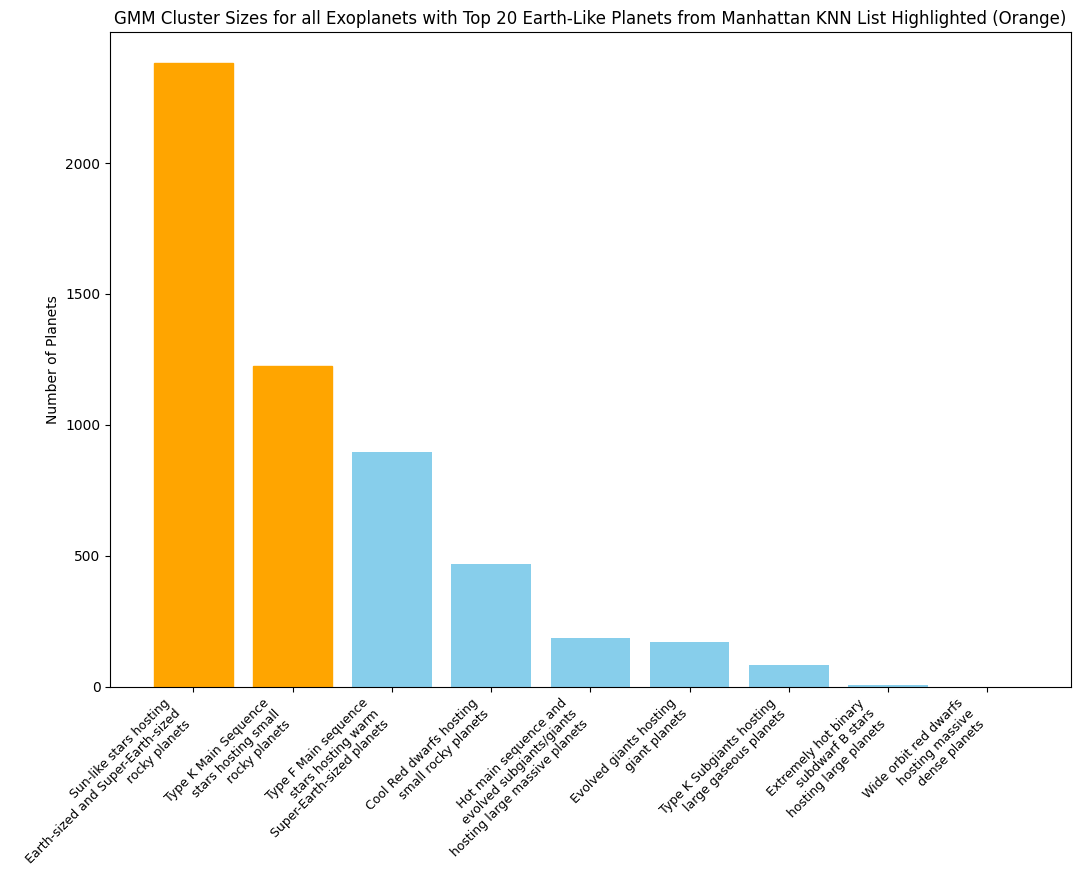

In [219]:
# Cluster counts from your GMM prediction
cluster_counts = {
    2: 2380,
    0: 1226,
    7: 897,
    4: 468,
    1: 187,
    5: 171,
    3: 83,
    8: 6,
    6: 1
}

# Names for clusters (same as your GMM labels)
cluster_names_gmm = {
    0: "Type K Main Sequence\n stars hosting small\n rocky planets",
    1: "Hot main sequence and\n evolved subgiants/giants\n hosting large massive planets",
    2: "Sun-like stars hosting\n Earth-sized and Super-Earth-sized\n rocky planets",
    3: "Type K Subgiants hosting\n large gaseous planets",
    4: "Cool Red dwarfs hosting\n small rocky planets",
    5: "Evolved giants hosting\n giant planets",
    6: "Wide orbit red dwarfs\n hosting massive\n dense planets",
    7: "Type F Main sequence\n stars hosting warm\n Super-Earth-sized planets",
    8: "Extremely hot binary\n subdwarf B stars\n hosting large planets"
}

# Top 20 Earth-like planets predicted cluster IDs for KNN manhattan list
top_20_clusters = gmm.predict(closest_planets_man_scaled)

# Create DataFrame for plotting
df = pd.DataFrame({
    "Cluster": [cluster_names_gmm[i] for i in cluster_counts.keys()],
    "Count": cluster_counts.values()
})

# Plot
plt.figure(figsize=(11,9))
bars = plt.bar(df['Cluster'], df['Count'], color='skyblue')

# Highlight clusters containing top Earth-like planets
highlight_clusters = set(top_20_clusters)
for i, c in enumerate(cluster_counts.keys()):
    if c in highlight_clusters:
        bars[i].set_color('orange')

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylabel("Number of Planets")
plt.title("GMM Cluster Sizes for all Exoplanets with Top 20 Earth-Like Planets from Manhattan KNN List Highlighted (Orange)")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(


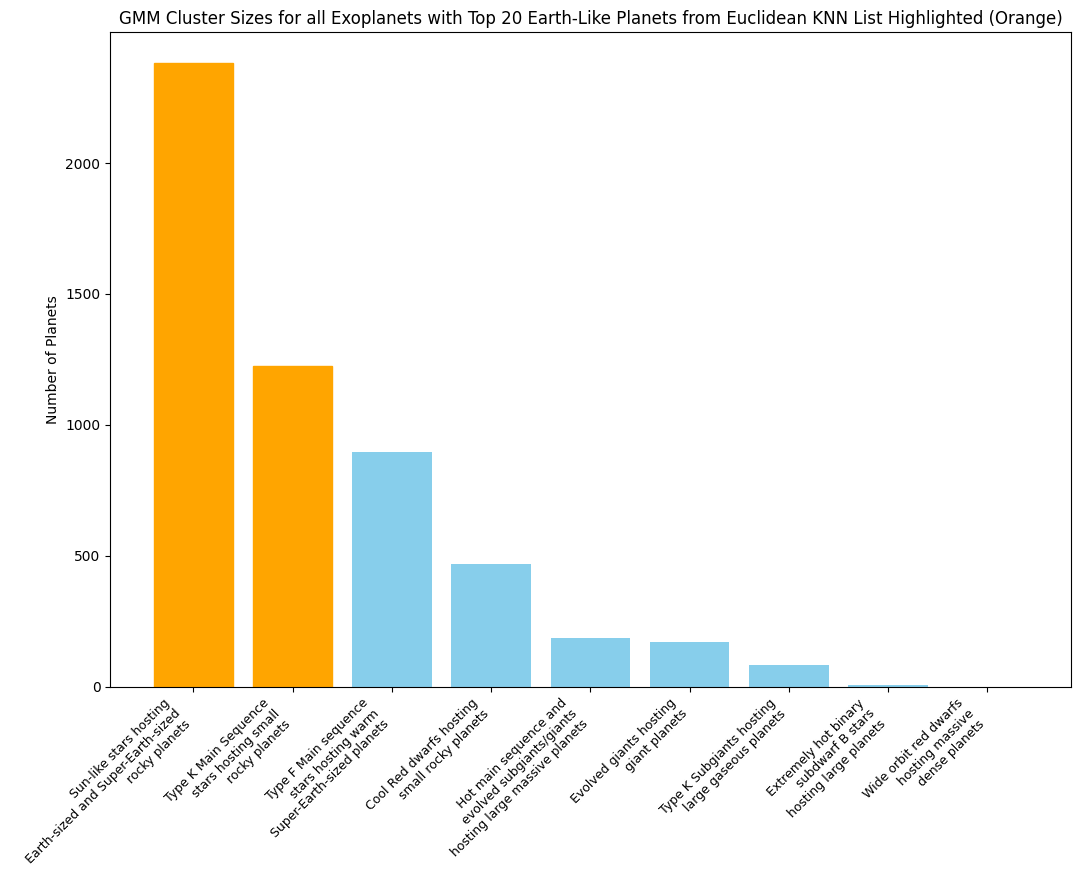

In [220]:
# Cluster counts from your GMM prediction
cluster_counts = {
    2: 2380,
    0: 1226,
    7: 897,
    4: 468,
    1: 187,
    5: 171,
    3: 83,
    8: 6,
    6: 1
}

# Names for clusters (same as your GMM labels)
cluster_names_gmm = {
    0: "Type K Main Sequence\n stars hosting small\n rocky planets",
    1: "Hot main sequence and\n evolved subgiants/giants\n hosting large massive planets",
    2: "Sun-like stars hosting\n Earth-sized and Super-Earth-sized\n rocky planets",
    3: "Type K Subgiants hosting\n large gaseous planets",
    4: "Cool Red dwarfs hosting\n small rocky planets",
    5: "Evolved giants hosting\n giant planets",
    6: "Wide orbit red dwarfs\n hosting massive\n dense planets",
    7: "Type F Main sequence\n stars hosting warm\n Super-Earth-sized planets",
    8: "Extremely hot binary\n subdwarf B stars\n hosting large planets"
}

# Top 20 Earth-like planets predicted cluster IDs for KNN euclidean list
top_20_clusters = gmm.predict(closest_planets_euc_scaled)

# Create DataFrame for plotting
df = pd.DataFrame({
    "Cluster": [cluster_names_gmm[i] for i in cluster_counts.keys()],
    "Count": cluster_counts.values()
})

# Plot
plt.figure(figsize=(11,9))
bars = plt.bar(df['Cluster'], df['Count'], color='skyblue')

# Highlight clusters containing top Earth-like planets
highlight_clusters = set(top_20_clusters)
for i, c in enumerate(cluster_counts.keys()):
    if c in highlight_clusters:
        bars[i].set_color('orange')

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylabel("Number of Planets")
plt.title("GMM Cluster Sizes for all Exoplanets with Top 20 Earth-Like Planets from Euclidean KNN List Highlighted (Orange)")
plt.tight_layout()
plt.show()

----
### **Guassian Mixture Model #2 (With One Hot Encoding on Categorical Features + Standard Scaling on all Features + Outliers Removed)**

In [204]:
# Define GMM using a covariance type = full
gmm2 = GaussianMixture(n_components=4, covariance_type='full', random_state=42)

# Fit model
gmm2_labels = gmm2.fit_predict(new_exoplanets_filtered_GMM_cleaned)

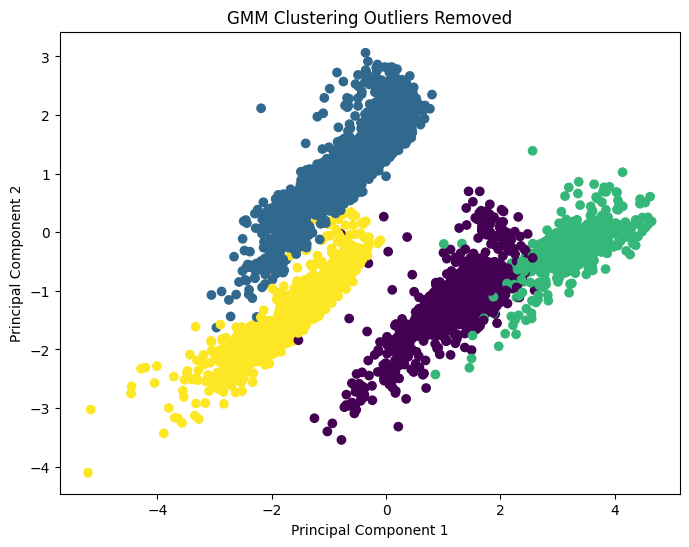

In [205]:
pca = PCA(n_components=2)
data_pca = pca.fit_transform(new_exoplanets_filtered_GMM_cleaned)

plt.figure(figsize=(8,6))
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=gmm2_labels)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("GMM Clustering Outliers Removed")
plt.show()

Like the K Means model #2, 4 clusters were used. and similar to the K Means mdoel #2 PCA graph, after removing outliers, there appears to be 4 distinct clusters with minor overlapping between the purple and green clusters.

In [208]:
# Evaluating GMM using Silhouette score
gmm_score2 = silhouette_score(new_exoplanets_filtered_GMM_cleaned, gmm2_labels)
print("Silhouette Score for GMM:", gmm_score2)

# Evaluating GMM using AIC (Akaike Information Criterion)
gmm_aic_score2 = gmm2.aic(new_exoplanets_filtered_GMM_cleaned)
print("AIC (Akaike Information Criterion) for GMM:", gmm_aic_score2)

# Evaluating GMM using BIC (Bayesian Information Criterion)
gmm_bic_score2 = gmm2.bic(new_exoplanets_filtered_GMM_cleaned)
print("BIC (Bayesian Information Criterion) for GMM:", gmm_bic_score2)

Silhouette Score for GMM: 0.483204086193876
AIC (Akaike Information Criterion) for GMM: -1365006.9816160654
BIC (Bayesian Information Criterion) for GMM: -1348649.3013511195


The silhoutte score increased from 0.42 (as found from the GMM model #1) to 0.483 which is comparable to the K Means model #2 silhoutte score of 0.483. Therefore, showing that by removing outlier planets, GMM performs better in seperating clusters.

The increased AIC and BIC scores imply a slightly better fit of the data well relative to its complexity.

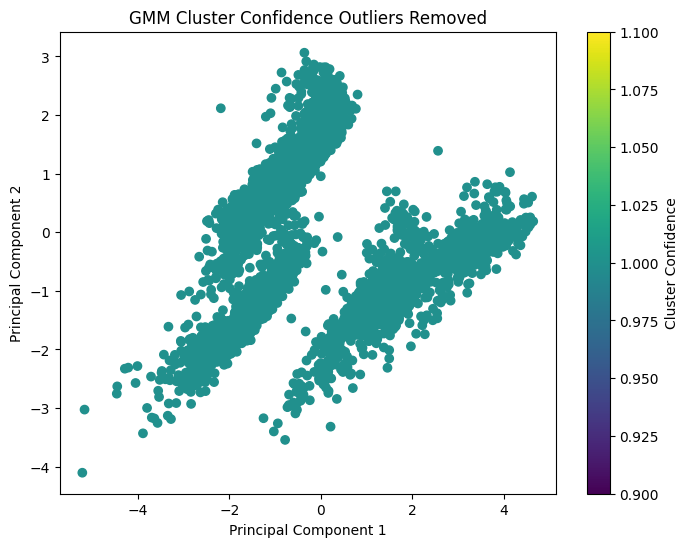

In [209]:
# Get membership probabilities
probabilities2 = gmm2.predict_proba(new_exoplanets_filtered_GMM_cleaned)

# Get maximum probability per planet
max_probs2 = np.max(probabilities2, axis=1)

plt.figure(figsize=(8,6))
scatter = plt.scatter(
    data_pca[:, 0],
    data_pca[:, 1],
    c=max_probs2,
    vmin=0.9,
    vmax=1.1
)
plt.colorbar(scatter, label="Cluster Confidence")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("GMM Cluster Confidence Outliers Removed")
plt.show()

In [210]:
# To verify strong probabilistic membership print
print("minimum prob:", max_probs2.min())
print("maximum prob:", max_probs2.max())
print("percentiles:", np.percentile(max_probs2, [5,25,50,75,95]))

minimum prob: 1.0
maximum prob: 1.0
percentiles: [1. 1. 1. 1. 1.]


After removing the outliers, the membership probability increased slightly. Therefore, GMM model #2 shows that the clusters became more compact. Gaussian distributions fit the data much more tightly. The model became more confident in assignments.

Similar to the result from GMM model #1, the high probability membership indicates high confidence that exoplanets belong to the correct cluster.

In [213]:
# interpreting centroid cluster values to interpret planetary system
gmm2 = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
gmm2.fit(new_exoplanets_filtered_GMM_cleaned)

# Get column names BEFORE scaling
feature_columns = new_exoplanets_filtered_GMM.columns

# Create a DataFrame of GMM cluster means
gmm2_cluster_centers_df = pd.DataFrame(
    gmm2.means_,
    columns=feature_columns)

cluster_centers_transposed_gmm2 = gmm2_cluster_centers_df.T
cluster_centers_transposed_gmm2

,0,1,2,3
star_number_per_system,-0.001507,-0.074354,0.075813,0.045141
orbital_period_day,-0.013873,-0.013871,-0.010708,-0.013884
orbit_semi_major_axis_au,-0.018710,-0.023709,-0.000495,-0.024074
planet_rad_earth_rad,-0.243536,-0.123160,-0.341554,0.027535
planet_mass_earth_mass,-0.176840,-0.137451,-0.203228,-0.032785
planet_equil_temp_k,-0.201112,0.083906,-0.727108,0.506144
stellar_effective_temp_k,-0.503091,0.219154,-1.423502,0.643183
stellar_rad_solar_rad,-0.182737,-0.112138,-0.280064,-0.037834
stellar_mass_solar_mass,-0.531696,0.068920,-1.444067,0.608625
stellar_surf_grav,0.429214,0.036231,1.053196,-0.253765


Interpretation:
* cluster 0: Type K Main Sequence stars hosting Earth-sized rocky planets
* cluster 1: Sun-Like stars hosting Earth-sized and Super-Earth-sized rocky planets
* Cluster 2: Cool red dwarf stars hosting Earth-sized rocky planets
* CLuster 3: Type F Main Sequence stars hosting warm Earth-sized rocky planets

In [214]:
# renaming the clusters based on the interpretation
cluster_centers_transposed_gmm2.columns = [
    "Type K Main Sequence stars hosting Earth-sized rocky planets",
    "Sun-Like stars hosting Earth-sized and Super-Earth-sized rocky planets",
    "Cool red dwarf stars hosting Earth-sized rocky planets",
    "Type F Main Sequence stars hosting warm Earth-sized rocky planets"
]

cluster_centers_transposed_gmm2

,Type K Main Sequence stars hosting Earth-sized rocky planets,Sun-Like stars hosting Earth-sized and Super-Earth-sized rocky planets,Cool red dwarf stars hosting Earth-sized rocky planets,Type F Main Sequence stars hosting warm Earth-sized rocky planets
star_number_per_system,-0.001507,-0.074354,0.075813,0.045141
orbital_period_day,-0.013873,-0.013871,-0.010708,-0.013884
orbit_semi_major_axis_au,-0.018710,-0.023709,-0.000495,-0.024074
planet_rad_earth_rad,-0.243536,-0.123160,-0.341554,0.027535
planet_mass_earth_mass,-0.176840,-0.137451,-0.203228,-0.032785
planet_equil_temp_k,-0.201112,0.083906,-0.727108,0.506144
stellar_effective_temp_k,-0.503091,0.219154,-1.423502,0.643183
stellar_rad_solar_rad,-0.182737,-0.112138,-0.280064,-0.037834
stellar_mass_solar_mass,-0.531696,0.068920,-1.444067,0.608625
stellar_surf_grav,0.429214,0.036231,1.053196,-0.253765


In [216]:
cluster_names_gmm2 = {
    0: "Type K Main Sequence stars hosting Earth-sized rocky planets",
    1: "Sun-Like stars hosting Earth-sized and Super-Earth-sized rocky planets",
    2: "Cool red dwarf stars hosting Earth-sized rocky planets",
    3: "Type F Main Sequence stars hosting warm Earth-sized rocky planets"
}

# predicting which clusters the top 20 Earth Like exoplanets belong to

# Get the feature rows directly from the original dataset
closest_planets_man_df = new_exoplanets_filtered_GMM.loc[closest_planets_man]
closest_planets_euc_df = new_exoplanets_filtered_GMM.loc[closest_planets_euc]

# Ensure feature order matches training data
closest_planets_man_df = closest_planets_man_df[new_exoplanets_filtered_GMM.columns]
closest_planets_euc_df = closest_planets_euc_df[new_exoplanets_filtered_GMM.columns]

# Scale features using the same scaler used for training
closest_planets_man_scaled = scaler.transform(closest_planets_man_df)
closest_planets_euc_scaled = scaler.transform(closest_planets_euc_df)

# Predict clusters
predict_cluster_man_cleaned = gmm2.predict(closest_planets_man_scaled)
predict_cluster_euc_cleaned = gmm2.predict(closest_planets_euc_scaled)

# Print Manhattan results
print("Top Earth-Like Exoplanets using Manhattan Distance (KNN Model #1 Results):")

for i, planet in enumerate(closest_planets_man):
    cluster_id = predict_cluster_man_cleaned[i]
    cluster_name = cluster_names_gmm2.get(cluster_id, "Unknown Cluster")
    print(f"{i+1}. {planet} (Cluster {cluster_id}: {cluster_name})")

# Print Euclidean results
print("\nTop Earth-Like Exoplanets using Euclidean Distance (KNN Model #2 Results):")

for i, planet in enumerate(closest_planets_euc):
    cluster_id = predict_cluster_euc_cleaned[i]
    cluster_name = cluster_names_gmm2.get(cluster_id, "Unknown Cluster")
    print(f"{i+1}. {planet} (Cluster {cluster_id}: {cluster_name})")

Top Earth-Like Exoplanets using Manhattan Distance (KNN Model #1 Results):
1. Kepler-452 b (Cluster 1: Sun-Like stars hosting Earth-sized and Super-Earth-sized rocky planets)
2. Kepler-1638 b (Cluster 1: Sun-Like stars hosting Earth-sized and Super-Earth-sized rocky planets)
3. Kepler-51 e (Cluster 1: Sun-Like stars hosting Earth-sized and Super-Earth-sized rocky planets)
4. Kepler-1606 b (Cluster 1: Sun-Like stars hosting Earth-sized and Super-Earth-sized rocky planets)
5. Kepler-1701 b (Cluster 1: Sun-Like stars hosting Earth-sized and Super-Earth-sized rocky planets)
6. Kepler-22 b (Cluster 1: Sun-Like stars hosting Earth-sized and Super-Earth-sized rocky planets)
7. Kepler-1126 c (Cluster 1: Sun-Like stars hosting Earth-sized and Super-Earth-sized rocky planets)
8. Kepler-1549 b (Cluster 1: Sun-Like stars hosting Earth-sized and Super-Earth-sized rocky planets)
9. Kepler-1690 b (Cluster 1: Sun-Like stars hosting Earth-sized and Super-Earth-sized rocky planets)
10. Kepler-69 c (Clus

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(


GMM model #2 and GMM model #1 are consistent with K Means model #2 and K Means model #1.

In [217]:
# viewing how many planets overall in the dataset are in each cluster
pd.Series(gmm2.predict(new_exoplanets_filtered_GMM_cleaned)).value_counts()

,count
1,2369
0,1165
3,886
2,464


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(


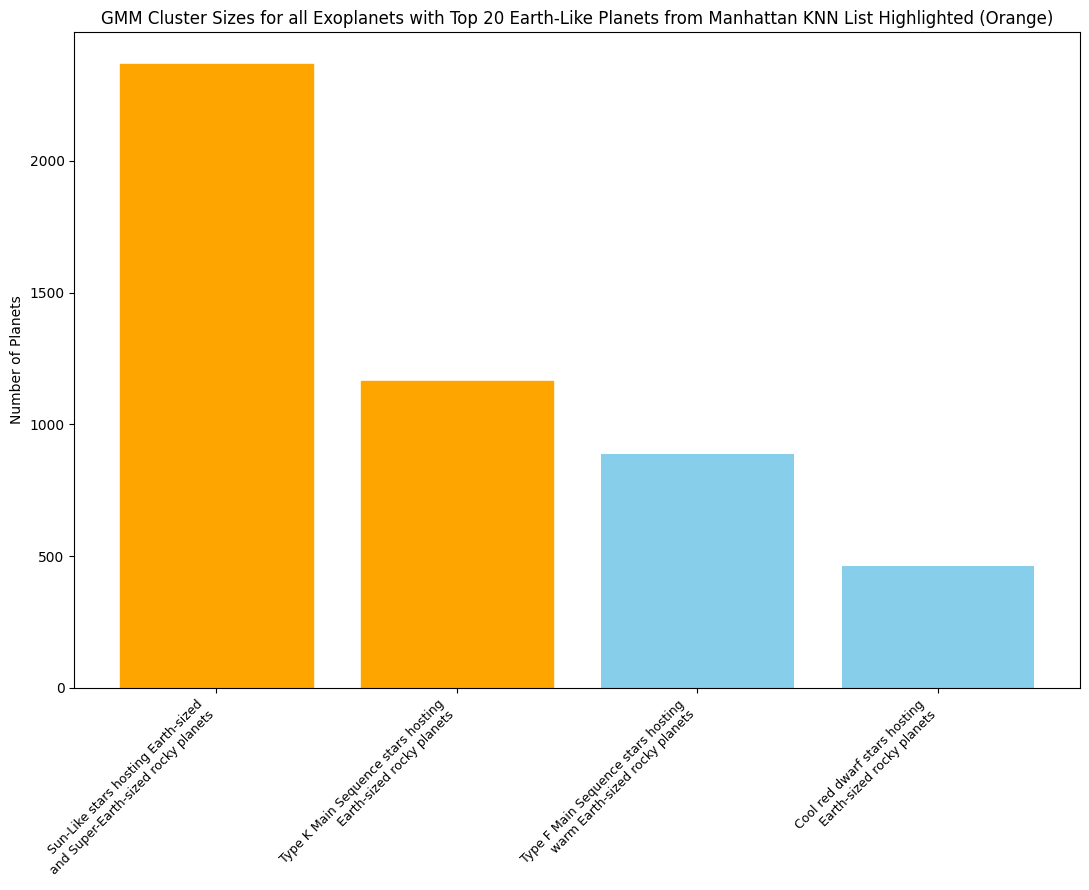

In [226]:
# Cluster counts from your GMM prediction
cluster_counts2 = {
    1: 2369,
    0: 1165,
    3: 886,
    2: 464
}

# Names for clusters (same as your GMM labels)
cluster_names_gmm2 = {
    0: "Type K Main Sequence stars hosting\n Earth-sized rocky planets",
    1: "Sun-Like stars hosting Earth-sized\n and Super-Earth-sized rocky planets",
    2: "Cool red dwarf stars hosting\n Earth-sized rocky planets",
    3: "Type F Main Sequence stars hosting\n warm Earth-sized rocky planets"
}

# Top 20 Earth-like planets predicted cluster IDs from manhattan KNN list
top_20_clusters2 = gmm2.predict(closest_planets_man_scaled)

# Create DataFrame for plotting
df = pd.DataFrame({
    "Cluster": [cluster_names_gmm2[i] for i in cluster_counts2.keys()],
    "Count": cluster_counts2.values()
})

# Plot
plt.figure(figsize=(11,9))
bars = plt.bar(df['Cluster'], df['Count'], color='skyblue')

# Highlight clusters containing top Earth-like planets
highlight_clusters2 = set(top_20_clusters2)
for i, c in enumerate(cluster_counts2.keys()):
    if c in highlight_clusters2:
        bars[i].set_color('orange')

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylabel("Number of Planets")
plt.title("GMM Cluster Sizes for all Exoplanets with Top 20 Earth-Like Planets from Manhattan KNN List Highlighted (Orange)")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(


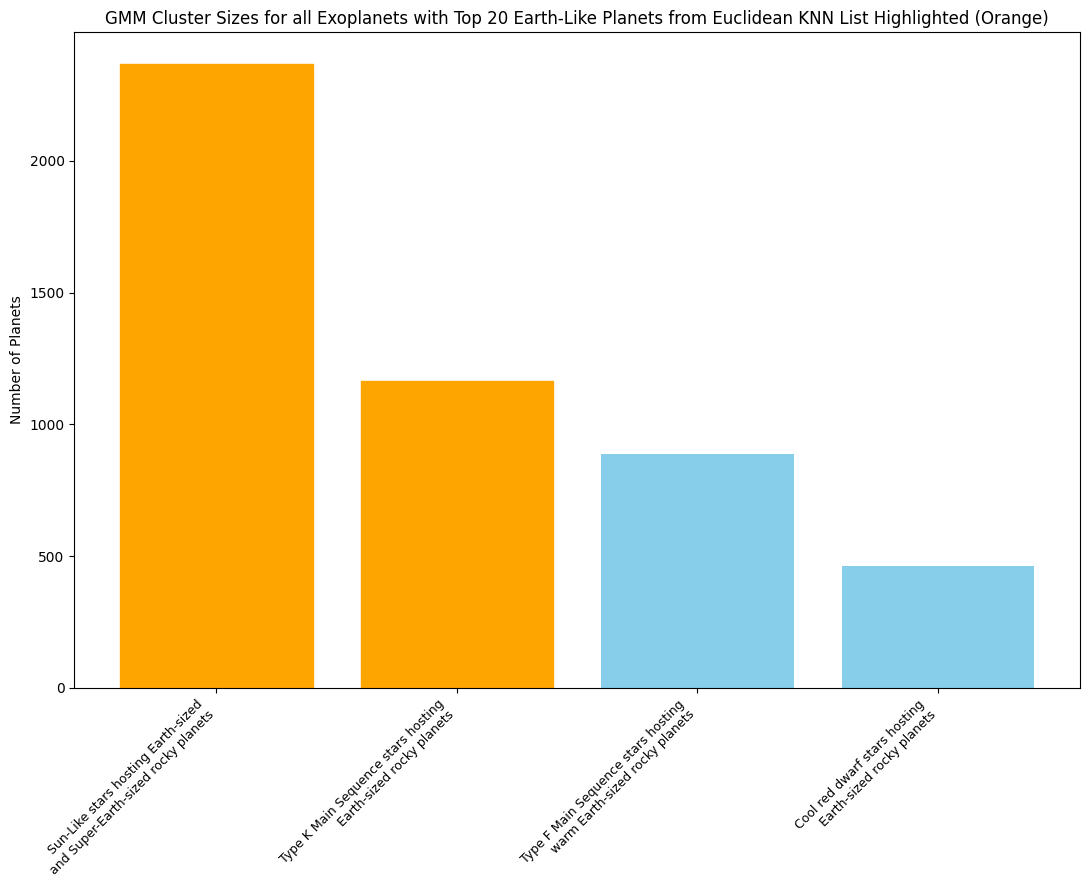

In [227]:
# Cluster counts from your GMM prediction
cluster_counts2 = {
    1: 2369,
    0: 1165,
    3: 886,
    2: 464
}

# Names for clusters (same as your GMM labels)
cluster_names_gmm2 = {
    0: "Type K Main Sequence stars hosting\n Earth-sized rocky planets",
    1: "Sun-Like stars hosting Earth-sized\n and Super-Earth-sized rocky planets",
    2: "Cool red dwarf stars hosting\n Earth-sized rocky planets",
    3: "Type F Main Sequence stars hosting\n warm Earth-sized rocky planets"
}

# Top 20 Earth-like planets predicted cluster IDs from euclidean KNN list
top_20_clusters2 = gmm2.predict(closest_planets_euc_scaled)

# Create DataFrame for plotting
df = pd.DataFrame({
    "Cluster": [cluster_names_gmm2[i] for i in cluster_counts2.keys()],
    "Count": cluster_counts2.values()
})

# Plot
plt.figure(figsize=(11,9))
bars = plt.bar(df['Cluster'], df['Count'], color='skyblue')

# Highlight clusters containing top Earth-like planets
highlight_clusters2 = set(top_20_clusters2)
for i, c in enumerate(cluster_counts2.keys()):
    if c in highlight_clusters2:
        bars[i].set_color('orange')

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylabel("Number of Planets")
plt.title("GMM Cluster Sizes for all Exoplanets with Top 20 Earth-Like Planets from Euclidean KNN List Highlighted (Orange)")
plt.tight_layout()
plt.show()

---
## **Unsupervised Learning - Density-Based Clustering (DBSCAN) & Hierarchical Density-Based Spatial Clustering (HDBSCAN)**
DBSCAN groups data points based on regions of high density and can find clusters of arbitrary shape. It designates points that aren’t dense enough as noise or outliers. Therefore, DBSCAN is effective for detecting clusters of arbitrary shapes and identifying outliers. Best for non-spherical clusters and outlier detection. Detects arbitrary-shaped clusters, finds outliers	Sensitive to parameter selection

Hierarchical Density-Based Spatial Clustering (HDBSCAN) is an advanced, unsupervised machine learning algorithm that finds clusters of varying density by building a hierarchy of clusters, separating them from sparse noise, and selecting the most stable clusters. It is a significant improvement over DBSCAN because it does not require a fixed density threshold to find clusters

In [228]:
# making a copy of the scaled K Means dataset to use for the DBSCAN and HDBSCAN model
new_exoplanets_filtered_dbscan_scaled = new_exoplanets_filtered_KMeans_scaled.copy()

### **DBSCAN Clustering Model**

In [229]:
from sklearn.cluster import DBSCAN

# define pipeline
dbscan_pipeline = Pipeline([
    ('dbscan', DBSCAN(eps=0.5, min_samples=10))
])

# fit and predict our clusters
dbscan_labels = dbscan_pipeline.fit_predict(new_exoplanets_filtered_dbscan_scaled,)

print(dbscan_labels)

[-1 -1 -1 ... -1 -1 -1]


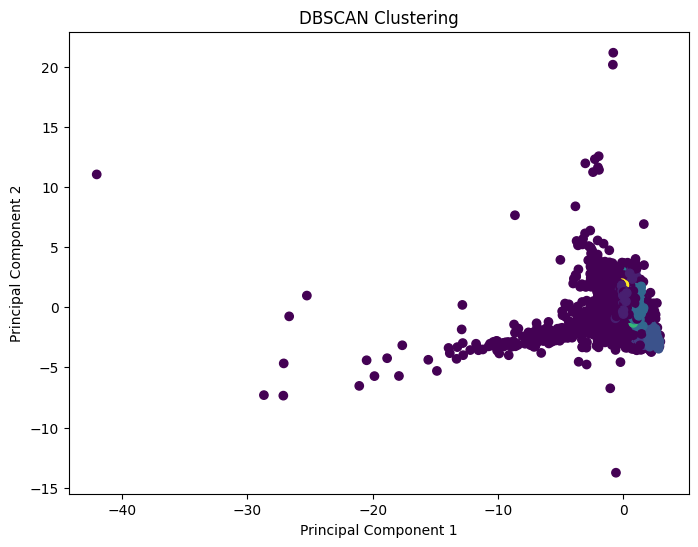

In [230]:
# visualization using PCA
pca = PCA(n_components=2)
data_pca = pca.fit_transform(new_exoplanets_filtered_dbscan_scaled)

plt.figure(figsize=(8,6))
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=dbscan_labels)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('DBSCAN Clustering')
plt.show()

In [231]:
# checking accuracy of model
dbscan_score = silhouette_score(new_exoplanets_filtered_dbscan_scaled, dbscan_labels)
print("Silhouette Score for DBSCAN Clustering: ", dbscan_score)

Silhouette Score for DBSCAN Clustering:  0.20130185014750898


Will not use DCSCAN for this analysis due to low score

### **HDBSCAN Clustering Model**

In [277]:
import hdbscan

hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=15,   # minimum number of planets (neighbors) required to form a cluster 30
    min_samples=5         # controls how strict the minimum cluster density requirement is 10, 5
)

hdbscan_labels = hdbscan_model.fit_predict(new_exoplanets_filtered_dbscan_scaled)
print(hdbscan_labels)

[ 0  5  5 ... 11  0  5]


HDBSCAN assigns a cluster label to each data point.

But unlike K-Means, HDBSCAN:
* does not guarantee a fixed number of clusters
* can discover clusters automatically
* can label some points as noise/outliers.

Therefore, exoplanets identified as noise/outliers are given the label of -1. While clusters of exoplanets given the labels 0, 1, 2, 3, etc...

In [278]:
# check how many noise planets were found
noise_planets = list(hdbscan_labels).count(-1)

print("Noise planets:", noise_planets)

Noise planets: 118


In [279]:
# using HDBSCAN to automatically determine the how many clusters were found
# len(set(hdbscan_labels)) finds the number of all unique clusters. This includes noise planets (label of -1)
# to remove the noise planets, we look for if the label is -1, then subtract. Else, subtract 0
n_clusters = len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
n_clusters_with_noise = len(set(hdbscan_labels))

print("Number of clusters:", n_clusters)
print("Number of clusters with noise planets included:", n_clusters_with_noise)

Number of clusters: 17
Number of clusters with noise planets included: 18


Unlike K Means or GMM where we choose the number of clusters k when fitting the model, HDBSCAN automatically discovers n number of clusters after fitting the model.

Points that do not belong to any dense region are labeled as noise (cluster label −1). To determine the number of meaningful clusters discovered by the model, the number of unique cluster labels was computed while excluding the noise label. This allows the algorithm to reveal the natural grouping structure of exoplanetary systems without forcing all observations into predefined clusters.

Therefore, the HDBSCAN model detected 15 natural planetary system groups along with 398 individual noise planets which exist in the dataset.

In [280]:
# Evaluate the silhouette score to assess model performance while excluding noise datapoints (planets)
mask = hdbscan_labels != -1

score = silhouette_score(
    new_exoplanets_filtered_dbscan_scaled[mask],
    hdbscan_labels[mask]
)

print("Silhouette Score:", score)

Silhouette Score: 0.5196056784445503


The silhoutte score of 0.513 is higher than both K Means Model #1 and K Means Model #2 silhoutte scores  as well as for GMM Model silhoutte score. This silhoutte score indicates fairly structured well defined clusters though minor overlapping may still be present.

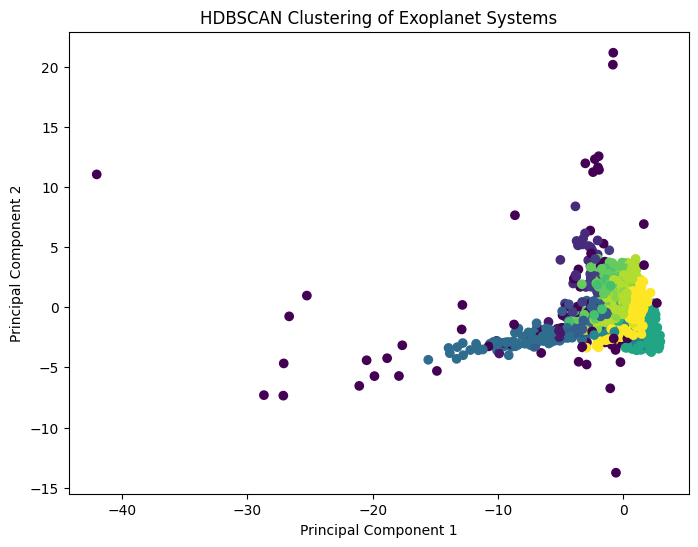

In [281]:
pca = PCA(n_components=2)
data_pca = pca.fit_transform(new_exoplanets_filtered_dbscan_scaled)

plt.figure(figsize=(8,6))
plt.scatter(
    data_pca[:,0],
    data_pca[:,1],
    c=hdbscan_labels,
    cmap='viridis'
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title("HDBSCAN Clustering of Exoplanet Systems")

plt.show()

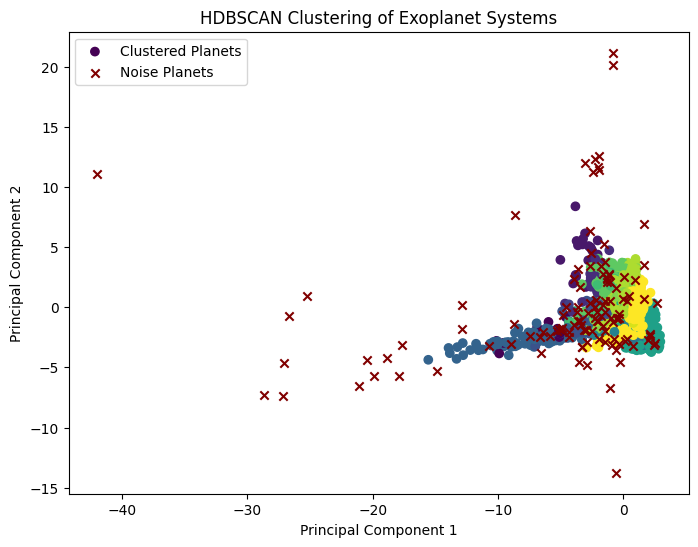

In [282]:
plt.figure(figsize=(8,6))

# Clustered points (labels >= 0)
mask_clusters = hdbscan_labels != -1
plt.scatter(
    data_pca[mask_clusters, 0],
    data_pca[mask_clusters, 1],
    c=hdbscan_labels[mask_clusters],
    cmap='viridis',
    label='Clustered Planets'
)

# Noise points (label == -1)
mask_noise = hdbscan_labels == -1
plt.scatter(
    data_pca[mask_noise, 0],
    data_pca[mask_noise, 1],
    c='maroon',
    marker='x',
    label='Noise Planets'
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title("HDBSCAN Clustering of Exoplanet Systems")
plt.legend()
plt.show()

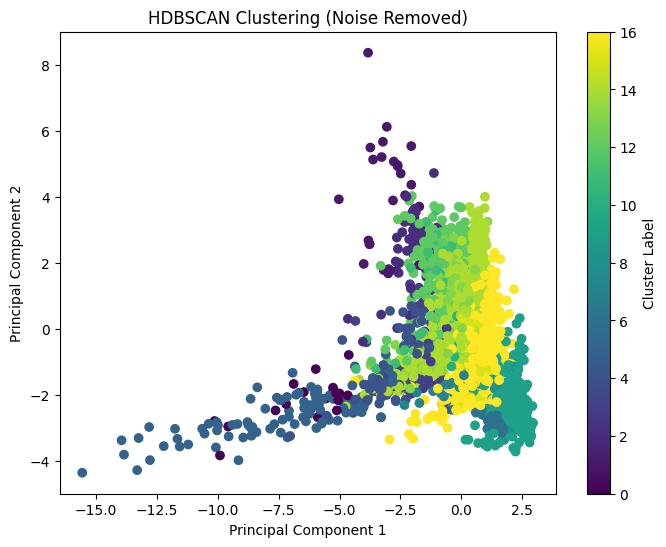

In [283]:
# Mask to exclude noise
mask_clusters = hdbscan_labels != -1

# PCA-transformed data without noise
data_pca_clusters = data_pca[mask_clusters]
labels_clusters = hdbscan_labels[mask_clusters]

plt.figure(figsize=(8,6))
plt.scatter(
    data_pca_clusters[:, 0],
    data_pca_clusters[:, 1],
    c=labels_clusters,
    cmap='viridis'
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title("HDBSCAN Clustering (Noise Removed)")
plt.colorbar(label='Cluster Label')
plt.show()

HDBSCAN provides membership probabilities, which GMM also does but K-Means cannot. These values show how strongly each planet belongs to its cluster.

Interpretation:
* 0.9+ --> strong cluster membership
* 0.5–0.7 --> borderline planet

In astronomy this can identify transitional planetary systems.

In [284]:
# extracting HDBSCAN’s membership probabilities for every datapoint (planet)
probabilities = hdbscan_model.probabilities_
probabilities

array([0.56787311, 0.18063168, 0.60628471, ..., 0.31695858, 1.        ,
       0.70335719])

In [285]:
# Filter confident datapoints (planets) to understand well-clustered planets only
mask_confident = probabilities > 0.9
confident_planets = new_exoplanets_filtered_dbscan_scaled[mask_confident]
confident_labels = hdbscan_labels[mask_confident]

In [286]:
confident_planets

,star_number_per_system,orbital_period_day,orbit_semi_major_axis_au,planet_rad_earth_rad,planet_mass_earth_mass,planet_equil_temp_k,stellar_effective_temp_k,stellar_rad_solar_rad,stellar_mass_solar_mass,stellar_surf_grav,...,spectral_type_KII,spectral_type_KIII,spectral_type_KIV,spectral_type_KV,spectral_type_MIII,spectral_type_MV,spectral_type_SD,spectral_type_T,spectral_type_WD,spectral_type_sdB
planet_name,,,,,,,,,,,,,,,,,,,,,
24 Sex b,-0.291421,-0.013822,-0.014273,1.496099,0.420652,-0.913646,-0.216598,0.872812,1.512829,-2.000997,...,-0.019215,-0.145273,8.018052,-0.545291,-0.033293,-0.307451,-0.013586,-0.013586,-0.023535,-0.033293
24 Sex c,-0.291421,-0.013743,-0.007209,0.769157,-0.005348,-1.080075,-0.216598,0.872812,1.512829,-2.000997,...,-0.019215,-0.145273,8.018052,-0.545291,-0.033293,-0.307451,-0.013586,-0.013586,-0.023535,-0.033293
47 UMa b,-0.291421,-0.013706,-0.007060,1.775659,0.633883,-1.373418,0.371747,-0.083207,0.269113,-0.150400,...,-0.019215,-0.145273,-0.124719,-0.545291,-0.033293,-0.307451,-0.013586,-0.013586,-0.023535,-0.033293
47 UMa c,-0.291421,-0.013467,0.007163,0.475389,-0.125981,-1.462717,0.363671,-0.083207,0.193985,-0.150400,...,-0.019215,-0.145273,-0.124719,-0.545291,-0.033293,-0.307451,-0.013586,-0.013586,-0.023535,-0.033293
51 Peg b,-0.291421,-0.013904,-0.026382,0.396098,-0.153572,0.591180,0.296853,-0.081605,0.200234,-0.140534,...,-0.019215,-0.145273,-0.124719,-0.545291,-0.033293,-0.307451,-0.013586,-0.013586,-0.023535,-0.033293
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
rho CrB c,-0.291421,-0.013886,-0.022941,-0.215405,-0.297396,-0.804657,0.276947,-0.037685,-0.071104,-0.478362,...,-0.019215,-0.145273,-0.124719,-0.545291,-0.033293,-0.307451,-0.013586,-0.013586,-0.023535,-0.033293
rho CrB d,-0.291421,-0.013853,-0.019057,-0.265580,-0.303931,-1.115939,0.337780,-0.040844,-0.020698,-0.290826,...,-0.019215,-0.145273,-0.124719,-0.545291,-0.033293,-0.307451,-0.013586,-0.013586,-0.023535,-0.033293
rho CrB e,-0.291421,-0.013902,-0.025873,-0.512516,-0.325056,0.016714,0.337780,-0.040844,-0.020698,-0.290826,...,-0.019215,-0.145273,-0.124719,-0.545291,-0.033293,-0.307451,-0.013586,-0.013586,-0.023535,-0.033293


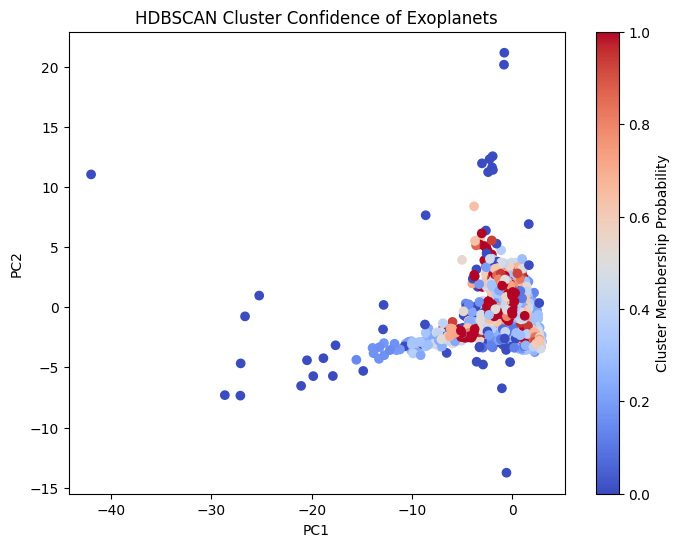

In [287]:
plt.figure(figsize=(8,6))
plt.scatter(
    data_pca[:,0],
    data_pca[:,1],
    c=probabilities,  # color by cluster confidence
    cmap='coolwarm'
)

plt.colorbar(label='Cluster Membership Probability')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title("HDBSCAN Cluster Confidence of Exoplanets")
plt.show()

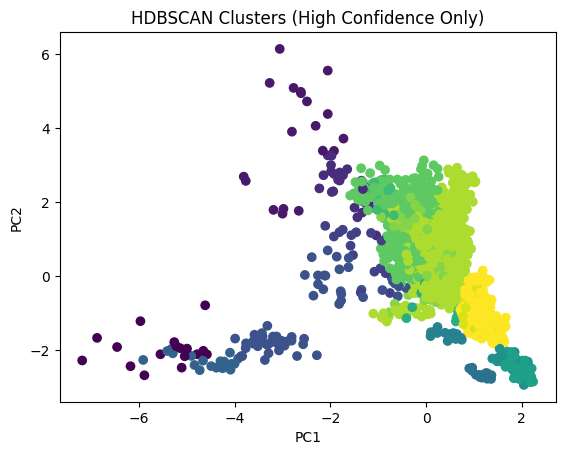

In [288]:
mask_high_prob = probabilities > 0.9
plt.scatter(
    data_pca[mask_high_prob,0],
    data_pca[mask_high_prob,1],
    c=hdbscan_labels[mask_high_prob],
    cmap='viridis'
)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title("HDBSCAN Clusters (High Confidence Only)")
plt.show()

HDBSCAN clustering was applied to the standardized exoplanet dataset to identify natural groupings without pre-specifying the number of clusters. Unlike K-Means and Gaussian Mixture Models, HDBSCAN identifies clusters based on density and allows for the detection of noise points representing atypical planetary systems. The model identified 15 distinct clusters while labeling 398 planets as noise, suggesting the presence of both well-defined planetary system types and rare outlier systems within the dataset.

In [305]:
# Get HDBSCAN labels and probabilities
hdb_labels = hdbscan_model.labels_
hdb_probs = hdbscan_model.probabilities_

# Create a DataFrame for convenience
hdb_df = pd.DataFrame({
    'planet_name': new_exoplanets_filtered_dbscan_scaled.index,
    'cluster': hdb_labels,
    'probability': hdb_probs
}).set_index('planet_name')

# Filter for top 20 Earth-like planets from Manhattan KNN List
top20_df_man = hdb_df.loc[closest_planets_man]
# Filter for top 20 Earth-like planets from Euclidean KNN List
top20_df_euc = hdb_df.loc[closest_planets_euc]

# Focus on most confident assignments where probability > 0.9 Manhattan KNN List
confident_top20_df_man = top20_df_man[top20_df_man['probability'] > 0.9]
# Focus on most confident assignments where probability > 0.9 Euclidean KNN List
confident_top20_df_euc = top20_df_euc[top20_df_euc['probability'] > 0.9]

# Count how many planets are in each cluster from Manhattan KNN List
cluster_counts_top20_man = confident_top20_df_man['cluster'].value_counts().sort_index()
# Count how many planets are in each cluster from Euclidean KNN List
cluster_counts_top20_euc = confident_top20_df_euc['cluster'].value_counts().sort_index()

print("Top 20 Earth-like planets from Manhattan KNN List in HDBSCAN clusters:")
print(cluster_counts_top20_man)
print("\nTop 20 Earth-like planets from Euclidean KNN List in HDBSCAN clusters:")
print(cluster_counts_top20_euc)

Top 20 Earth-like planets from Manhattan KNN List in HDBSCAN clusters:
cluster
6     11
7      2
13     1
14     5
Name: count, dtype: int64

Top 20 Earth-like planets from Euclidean KNN List in HDBSCAN clusters:
cluster
6     9
7     2
13    1
14    8
Name: count, dtype: int64


In [309]:
# Get top 20 planets with their HDBSCAN cluster and probability
top20_hdb_man = hdb_df.loc[closest_planets_man]
top20_hdb_euc = hdb_df.loc[closest_planets_euc]

# Include only confident assignments (probability > 0.9)
top20_hdb_conf_man = top20_hdb_man[top20_hdb_man['probability'] > 0.9]
top20_hdb_conf_euc = top20_hdb_euc[top20_hdb_euc['probability'] > 0.9]

# Create a readable table
top20_hdb_table_man = top20_hdb_conf_man.copy()
top20_hdb_table_euc = top20_hdb_conf_euc.copy()

top20_hdb_table_man = top20_hdb_table_man.reset_index()  # make planet_name a column
top20_hdb_table_euc = top20_hdb_table_euc.reset_index()  # make planet_name a column

top20_hdb_table_man.rename(columns={
    'cluster': 'HDBSCAN Cluster',
    'probability': 'Cluster Probability'
}, inplace=True)

top20_hdb_table_euc.rename(columns={
    'cluster': 'HDBSCAN Cluster',
    'probability': 'Cluster Probability'
}, inplace=True)

# Sort by cluster for readability
top20_hdb_table_man = top20_hdb_table_man.sort_values('HDBSCAN Cluster')
top20_hdb_table_euc = top20_hdb_table_euc.sort_values('HDBSCAN Cluster')

print("Top Earth-Like Planets from Manhattan KNN List and Their HDBSCAN Clusters:")
print(top20_hdb_table_man[['planet_name', 'HDBSCAN Cluster', 'Cluster Probability']])
print("\nTop Earth-Like Planets from Euclidean KNN List and Their HDBSCAN Clusters:")
print(top20_hdb_table_euc[['planet_name', 'HDBSCAN Cluster', 'Cluster Probability']])

Top Earth-Like Planets from Manhattan KNN List and Their HDBSCAN Clusters:
      planet_name  HDBSCAN Cluster  Cluster Probability
0    Kepler-452 b                6             1.000000
1   Kepler-1638 b                6             0.991900
2     Kepler-51 e                6             1.000000
3   Kepler-1606 b                6             1.000000
4   Kepler-1701 b                6             0.935295
5     Kepler-22 b                6             1.000000
7   Kepler-1549 b                6             1.000000
8   Kepler-1690 b                6             1.000000
11  Kepler-1634 b                6             1.000000
10  Kepler-1090 b                6             1.000000
16  Kepler-1554 b                6             0.927860
15   Kepler-442 b                7             0.979553
18  Kepler-1544 b                7             0.999139
14   Kepler-132 e               13             1.000000
6   Kepler-1126 c               14             1.000000
9     Kepler-69 c            

For the top 5 most Earth-like exoplanets they remain consistent in their cluster grouping of cluster 6 for both metrics (manhattan and euclidean). This once again confirms the robustness of Kepler-452 b, Kepler-1638 b, Kepler-51, Kepler-1606 b, and Kepler-1701 b being the most Earth-Like. This can be supported by the overall consistent results of the top 5 Earth-Like planets deomonstrated in KNN Model #1, KNN Model #2, K Means Model #1, K Means Model #2, GMM Model #1, and GMM Model #2.

The HDBSCAN model also reflects the results from KNN Model #1 and KNN Model #2 which showed that exoplanets ranked 6-20 displayed sensitivity to the metric and thus, depicted slight variability in its similarity to Earth. This is because the HDBSCAN model shows that certain exoplanets ranked 6-20 switched between cluster 6 to cluster 14. The exception to this is Kepler 1544 b and Kepler 442 b which both remained in cluster 7 due to the fact that these are the only two planets orbiting a KV star rather than a GV star like all other top 20 Earth like planets. kepler 132 e also remained in cluster 13 which reveals a very interesting oberservation where Kepler 132 e may be the only Earth-like exoplanet which has a possibility of being in a binary star system as supported by the table below which a strong signal of 2.751 for star_number_per_system whereas all other planets are likely a single star due to shared signal of > -0.3.

These results reveal that unlike K Means and GMM models, HDBSCAN is able to fine tune to further distinguish the top 20 Earth Like planets. Clusters 6 and 14 are likely very similar with only subtle differences planet mass and planet temperature as shown by the table below. Implying they are Earth-Like exoplanets orbiting GV stars where cluster 6 is likely Super-Earth sized and cluster 14 is Earth-sized. cluster 13 may be Earth-Like exoplanets orbiting binary stars and cluster 7 are Earth-like exoplanets orbiting KV stars.

In [301]:
# Filter only planets in clusters of interest
clusters_of_interest = [6, 7, 13, 14]
cluster_props = new_exoplanets_filtered_dbscan_scaled.copy()

# Add HDBSCAN cluster labels as a column
cluster_props['cluster'] = hdbscan_model.labels_

# Compute mean properties per cluster
cluster_summary = cluster_props[cluster_props['cluster'].isin(clusters_of_interest)].groupby('cluster').mean()

# Round for readability
cluster_summary_rounded = cluster_summary.round(3)

# Optional: display as a table
import tabulate
print(tabulate.tabulate(cluster_summary_rounded, headers='keys', tablefmt='grid'))

+-----------+--------------------------+----------------------+----------------------------+------------------------+--------------------------+-----------------------+----------------------------+-------------------------+---------------------------+---------------------+--------------------------------+---------------------------+---------------------------+----------------------+---------------------+--------------------+---------------------+--------------------+---------------------+--------------------+---------------------+----------------------+---------------------+--------------------+---------------------+----------------------+---------------------+--------------------+----------------------+--------------------+--------------------+-------------------+--------------------+---------------------+
|   cluster |   star_number_per_system |   orbital_period_day |   orbit_semi_major_axis_au |   planet_rad_earth_rad |   planet_mass_earth_mass |   planet_equil_temp_k |   stellar_ef